# CS7324 - Spring 2026 - Lab 5

* Group 19: Kristoffer Matsson, Arturo Perez Espinosa, Mike Truty
* Due: Sun 2026-04-19

## Grading Rubric

### 1. Preparation (4 points total)

* [1 points] Define and prepare your class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods (as needed) for dimensionality reduction, scaling, etc. Remove variables that are not needed/useful for the analysis. Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). You have the option of using tf.dataset for processing, but it is not required. 
* [1 points] Identify groups of features in your data that should be combined into cross-product features. Provide a compelling justification for why these features should be crossed (or why some features should not be crossed). 
* [1 points] Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.
* [1 points] Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Argue why your cross validation method is a realistic mirroring of how an algorithm would be used in practice. Use the method to split your data that you argue for. 

### 2. Modeling (5 points total)

* [2 points] Create at least three combined wide and deep networks to classify your data using Keras (this total of "three" includes the model you will train in the next step of the rubric). Visualize the performance of the network on the training data and validation data in the same plot versus the training iterations.
  * Note: you can use the "history" return parameter that is part of Keras "fit" function to easily access this data.
* [2 points] Investigate generalization performance by altering the number of layers in the deep branch of the network. Try at least two models (this "two" includes the wide and deep model trained from the previous step). Use the method of cross validation and evaluation metric that you argued for at the beginning of the lab to answer: What model with what number of layers performs superiorly? Use proper statistical methods to compare the performance of different models.
* [1 points] Compare the performance of your best wide and deep network to a standard multi-layer perceptron (MLP). Alternatively, you can compare to a network without the wide branch (i.e., just the deep network). For classification tasks, compare using the receiver operating characteristic and area under the curve. For regression tasks, use Bland-Altman plots and residual variance calculations.  Use proper statistical methods to compare the performance of different models.  

### 3. Exceptional Work (1 points total)

* 5000 students: You have free reign to provide additional analyses.
* One idea (required for 7000 level students): Capture the embedding weights from the deep network and (if needed) perform dimensionality reduction on the output of these embedding layers (only if needed). That is, pass the observations into the network, save the embedded weights (called embeddings), and then perform  dimensionality reduction in order to visualize results. Visualize and explain any clusters in the data.


## A note on AI code generation

In this lab, we used AI assistance for code generation significantly. We established our baseline using the exact code from the class notebook:
`10a. Keras Wide and Deep as TFData.ipynb`. But, writing code with AI is a collaborative experience. We spent a lot of time comparing and studying
the code vs the class notebook code. We asked questions and used visualizations significantly to understand the various learning objectives here:
handling features, using TensorFlow data, crossing features, embeddings, multi-layer model tuning, wide vs deep, and overall model metrics and 
comparisons. There are two areas we'd like to explore further:

1. Tuning these multi-layer models. How to choose the best: #layers, #neurons, regularization, dropout, etc. hyperparameters/settings. Methods
for doing this need more time/exploration.
2. Identifying correlated features. The work we did in Exceptional definitely created an apetite to more carefully explore feature relationships.


In [15]:
#import libraries

import kagglehub
import pandas as pd
import numpy as np
import os

## Data Import - from Kaggle

We selected a `canada-housing` dataset from Kaggle. 

In [16]:
# retrieve the path to the csv file 
kaggle_path = kagglehub.dataset_download("yuliiabulana/canada-housing")
print(f"Path to dataset files: {kaggle_path}")

file_name = "cleaned_canada.csv"
file_path = os.path.join(kaggle_path, file_name)
print(f"Selected file: {file_path}")

Using Colab cache for faster access to the 'canada-housing' dataset.
Path to dataset files: /kaggle/input/canada-housing
Selected file: /kaggle/input/canada-housing/cleaned_canada.csv


In [17]:
# Read the data and study the data types and missing values
df_raw = pd.read_csv(file_path)

print(df_raw.shape)

summary = df_raw.count().rename("non_nan_count").to_frame()
summary["nan_count"] = len(df_raw) - summary["non_nan_count"]
summary

(44896, 23)


,non_nan_count,nan_count
City,44896,0
Province,44896,0
Latitude,44896,0
Longitude,44896,0
Price,44896,0
Bedrooms,44896,0
Bathrooms,44896,0
Acreage,44896,0
Property Type,44896,0
Square Footage,44896,0


### Data shape

The raw data set is ~45k rows x 23 columns/features.
We'd prefer to avoid trying to model with features/columns with missing data.
We'll drop columns which have significant missing data. We chose: Basement,
Exterior, Heating, Flooring, and Roof since they all have many NaN values.
Overall, we're standardizing our model on homes in which one family might reside.
This will exclude lots, and multi-family homes. It will include studios, 1+ bedroom homes,
condos, and townhouses.

In [18]:
# Drop the columns which seem to have a lot of missing values and are not likely to be useful for modeling.
drop_columns = ['Basement', 'Exterior', 'Heating', 'Flooring', 'Roof']
df_no_nan = df_raw.drop(columns = drop_columns)
df_no_nan.dropna(inplace = True)
df_no_nan

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,Garage,Parking,Fireplace,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,Yes,Yes,No,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,Yes,Yes,No,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,No,No,No,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,Yes,No,Yes,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,Yes,Yes,No,No,none,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44891,Fort Nelson,BC,58.805426,-122.691717,289000.0,3.0,3.0,0.15,Single Family,2175.0,Yes,No,No,No,none,No,No,No
44892,La Crete,AB,58.184661,-116.421516,350000.0,4.0,3.0,0.23,Single Family,1056.0,Yes,Yes,No,No,none,No,Yes,No
44893,High Level,AB,58.517660,-117.143173,270000.0,4.0,2.0,0.22,Single Family,1075.0,Yes,Yes,Yes,No,none,No,No,No
44894,Whitehorse,YT,60.698432,-135.117177,749000.0,4.0,3.0,0.19,Single Family,2576.0,No,No,Yes,No,none,No,No,No


### Data cleaning

We think some of the property types won't make sense in our model for determining home prices.
Let's explore...

Below, we'll remove anything that doesn't really seem like a single-family-home.
We think the following should remain: "Single Family", "Condo", "Townhome", "Condo/Townhome".

Property Type
Single Family        26619
Condo                12593
Townhome              2237
Condo/Townhome        1655
Duplex                1056
MultiFamily            281
Mobile Home            228
Manufactured Home      211
Vacant Land             16
Name: count, dtype: int64


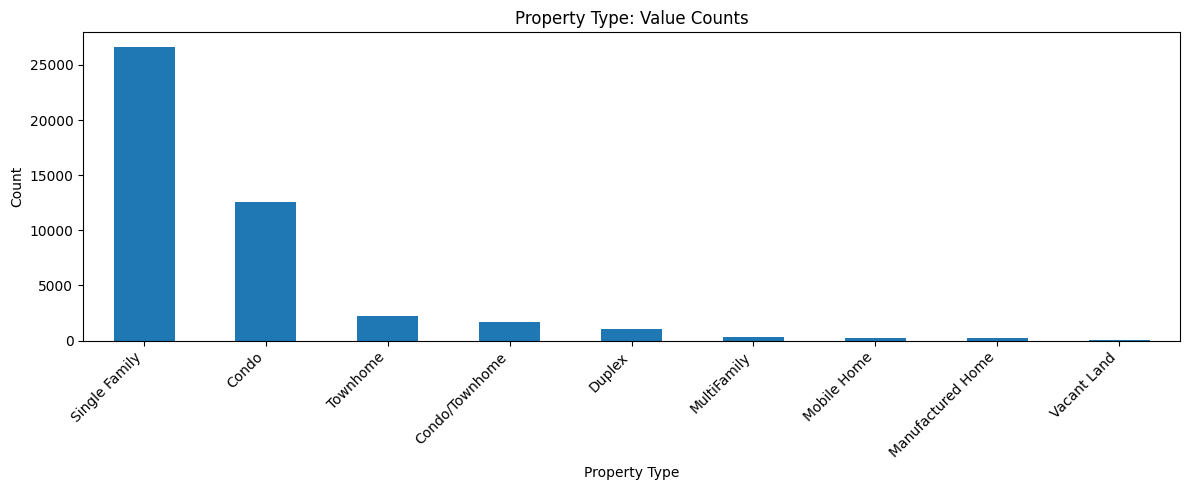

In [19]:
import matplotlib.pyplot as plt

property_type_counts = df_no_nan['Property Type'].value_counts(dropna=False).sort_values(ascending=False)
print(property_type_counts)

plt.figure(figsize=(12, 5))
property_type_counts.plot(kind='bar')
plt.title('Property Type: Value Counts')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Remove anything that is not: ["Single Family", "Condo", "Townhome", "Condo/Townhome"]
df_no_nan = df_no_nan[df_no_nan['Property Type'].isin(["Single Family", "Condo", "Townhome", "Condo/Townhome"])]
print(df_no_nan.shape)  

(43104, 18)


This dropped us from 44896 to 43104 rows, still with 18 columns, including our output: Price.

The other benefit here is this likely removed some other data that was likely marginalized.
For example, we know there were 439 rows where "Bedrooms" was actually 0.0.
Now there are 415.

But, Bedrooms = 0 might just be code for "studio", which is possible. The more concerning would be
Bathrooms = 0; what does that mean? Acreage = 0 could just be code for apartment/condo?

In [21]:
print((df_no_nan["Bedrooms"] <= 0.0).sum())
zero_bedrooms_rows = df_no_nan.loc[df_no_nan["Bedrooms"] == 0.0].copy()

print(f"Rows with Bedrooms = 0.0: {len(zero_bedrooms_rows)}")
display(zero_bedrooms_rows)

415
Rows with Bedrooms = 0.0: 415


,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,Garage,Parking,Fireplace,Waterfront,Sewer,Pool,Garden,Balcony
179,Big White,BC,49.721928,-118.925423,205000.0,0.0,1.0,0.00,Condo,462.0,No,Yes,No,No,municipal,No,No,No
207,Langley,BC,49.157610,-122.657681,589900.0,0.0,1.0,0.00,Condo,791.0,Yes,Yes,Yes,No,none,No,No,No
224,Surrey,BC,49.190813,-122.826820,409900.0,0.0,1.0,0.00,Condo,383.0,Yes,Yes,No,No,none,No,No,No
397,Coquitlam,BC,49.285773,-122.795780,624900.0,0.0,2.0,0.00,Condo,996.0,Yes,Yes,No,No,none,No,No,No
450,Vancouver,BC,49.251826,-123.237580,758800.0,0.0,1.0,0.00,Condo,471.0,Yes,Yes,No,No,none,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44175,Prince Albert,SK,53.199628,-105.801147,799900.0,0.0,0.0,0.00,Single Family,840.0,Yes,No,No,No,none,No,No,No
44639,Saskatoon,SK,52.117692,-106.682691,89900.0,0.0,0.0,0.07,Single Family,670.0,No,No,No,No,none,No,No,No
44670,Saskatoon,SK,52.133867,-106.671592,260000.0,0.0,2.0,0.14,Single Family,2360.0,No,Yes,No,No,none,No,No,No
44671,Saskatoon,SK,52.123927,-106.678563,105000.0,0.0,1.0,0.07,Single Family,338.0,No,Yes,No,No,none,No,No,No


We notice here that Bedrooms, Bathrooms, and Acreage can all be 0.00.
This is likely because some properties are listed as "Studio" or "Loft"
(which may have 0 bedrooms) or "Condo/Townhome" (which may have 0 acreage).


### Data output

We intend to use `Price` as our output class. We decided to attempt building a regression model here which
could predict a **price** for a home given input criteria.

We still have >43k rows with 17 feature columns, categorical and numeric. We should be good.

In [22]:
# show the dtypes
df_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43104 entries, 0 to 44895
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            43104 non-null  object 
 1   Province        43104 non-null  object 
 2   Latitude        43104 non-null  float64
 3   Longitude       43104 non-null  float64
 4   Price           43104 non-null  float64
 5   Bedrooms        43104 non-null  float64
 6   Bathrooms       43104 non-null  float64
 7   Acreage         43104 non-null  float64
 8   Property Type   43104 non-null  object 
 9   Square Footage  43104 non-null  float64
 10  Garage          43104 non-null  object 
 11  Parking         43104 non-null  object 
 12  Fireplace       43104 non-null  object 
 13  Waterfront      43104 non-null  object 
 14  Sewer           43104 non-null  object 
 15  Pool            43104 non-null  object 
 16  Garden          43104 non-null  object 
 17  Balcony         43104 non-null  obje

As demonstrated above, all features which were originally made up of string data have been converted to unique integers. This ensures that the data is all numeric and will still allow the use of embedding or one hot encoding later in the notebook.

There are no new features added to the dataset. So far, we have only cleaned up the data and modified the string data to be integers. 

We believe that all of the features shown above are of value and should be kept for the model. Although we originally wanted to drop the latitude and longitude features since we already have 'City' and 'Province' to cover geographic characters, we believe those two features would be useful for the model to characterize expensive neighborhoods or homes in which its price is heavily driven by a special location in a city. 

## Pre-processing

In [35]:
# Let's divide our 18 columns of data into: target (price), then features:
#     categorical, discretized, and numeric.
# We will use the categorical features to create crossed features for the wide branch of our model,
# and we will use the numeric features in the deep branch of our model.
# The categorical features will also be used in the deep branch of our model as well.

# In general, to use TensorFlow/Keras, need feature names to NOT include spaces.
# For example:
# "Property Type" -> "Property_Type"
# "Square Footage_bin" -> "Square_Footage_bin"
safe_name_map = {
    c: (
        c.strip()
         .replace(" ", "_")
         .replace("/", "_")
         .replace("-", "_")
    )
    for c in df_no_nan.columns
}
df_model = df_no_nan.rename(columns=safe_name_map)

target_col = "Price"
feature_cols = sorted([c for c in df_model.columns if c != target_col])

# Identify categorical columns by their type.
categorical_headers = [
    c for c in feature_cols
    if c in df_model.select_dtypes(include=["object", "category", "string"]).columns
]

# Everything else is numeric after preprocessing
numeric_headers = [c for c in feature_cols if c not in categorical_headers]

# We can discretized a few numeric columns since that seems to both improve performance
# and make these features more useful for crossing in the wide branch of our model.
discretized_source_headers = sorted([c for c in ["Square_Footage", "Acreage"] if c in numeric_headers])
discretized_headers = [f"{c}_bin" for c in discretized_source_headers]

continuous_numeric_headers = [c for c in numeric_headers if c not in discretized_source_headers]

print(f"Target: {target_col}")
print(f"Categorical: {categorical_headers}")
print(f"Discretized: {discretized_headers}")
print(f"Continuous numeric: {continuous_numeric_headers}")

Target: Price
Categorical: ['Balcony', 'City', 'Fireplace', 'Garage', 'Garden', 'Parking', 'Pool', 'Property_Type', 'Province', 'Sewer', 'Waterfront']
Discretized: ['Acreage_bin', 'Square_Footage_bin']
Continuous numeric: ['Bathrooms', 'Bedrooms', 'Latitude', 'Longitude']


### Split data first, then derive discretized features

We first separate features from the target and create a **70/15/15** train/validation/test split.
Because this is a regression problem, we stratify using **price quantile bins** so each partition contains a reasonable spread of lower-, middle-, and higher-priced homes.

Doing the split **before** learning bin edges or normalization statistics helps reduce leakage from the validation and test sets into training.

In [43]:
from sklearn.model_selection import train_test_split

# Split BEFORE learning any discretization bins or preprocessing statistics.
X = df_model.drop(columns=["Price"]).copy()
y = df_model["Price"].astype("float32").copy()

# Use price quantile bins only for stratification so each split has a similar
# spread of low-, mid-, and high-priced homes.
price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

# First split off 30% of the data for validation and test,
# then split that temp partition in half to get 15% val and 15% test.
X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X,
    y,
    price_bins,
    test_size=0.30,
    random_state=42,
    stratify=price_bins,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=bins_temp,
)

print(f"Train rows: {len(X_train)} ({len(X_train)/len(X):.1%})")
print(f"Validation rows: {len(X_val)} ({len(X_val)/len(X):.1%})")
print(f"Test rows: {len(X_test)} ({len(X_test)/len(X):.1%})")


Train rows: 30172 (70.0%)
Validation rows: 6466 (15.0%)
Test rows: 6466 (15.0%)


In [47]:
# This is sort of advanced. We want to use quantiles for these numeric features,
# but we want to learn the quantile bin edges ONLY from the training split so that the
# holdout validation and test partitions remain truly unseen.

# Learn quantile bin edges ONLY from the training split, then apply those same
# edges to validation and test so the holdout partitions remain truly unseen.
for col in discretized_source_headers:
    _, bin_edges = pd.qcut(
        X_train[col],
        q=20,
        labels=False,
        retbins=True,
        duplicates="drop",
    )
    bin_edges = np.unique(bin_edges)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    X_train[f"{col}_bin"] = pd.cut(
        X_train[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_val[f"{col}_bin"] = pd.cut(
        X_val[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_test[f"{col}_bin"] = pd.cut(
        X_test[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")

# Keep only the binned versions for these features in each split.
for split_df in (X_train, X_val, X_test):
    split_df.drop(columns=discretized_source_headers, inplace=True)


In [44]:
# We also want Bedrooms and Bathrooms available as coarse CATEGORICAL bins for
# the wide branch. These bins are rule-based, and we can then apply the same mapping
# consistently across train/validation/test data. We also want to be sure to handle
# any non-numeric values or missing values in these columns by treating them as 0.0
# (which will then fall into the lowest bin).

bedrooms_zero_count = (X_train["Bedrooms"] == 0.0).sum()
bathrooms_zero_count = (X_train["Bathrooms"] == 0.0).sum()
print(f'Count of X_train["Bedrooms"] == 0.0: {bedrooms_zero_count}')
print(f'Count of X_train["Bathrooms"] == 0.0: {bathrooms_zero_count}')

for split_df in (X_train, X_val, X_test):
    bedrooms_num = pd.to_numeric(split_df["Bedrooms"], errors="coerce")
    bedrooms_num = bedrooms_num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    split_df["Bedrooms_bin"] = pd.cut(
        bedrooms_num,
        bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf],
        labels=False,
        include_lowest=True,
    ).astype("int64")

    bathrooms_num = pd.to_numeric(split_df["Bathrooms"], errors="coerce")
    bathrooms_num = bathrooms_num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    split_df["Bathrooms_bin"] = pd.cut(
        bathrooms_num,
        bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf],
        labels=False,
        include_lowest=True,
    ).astype("int64")


Count of X_train["Bedrooms"] == 0.0: 279
Count of X_train["Bathrooms"] == 0.0: 175


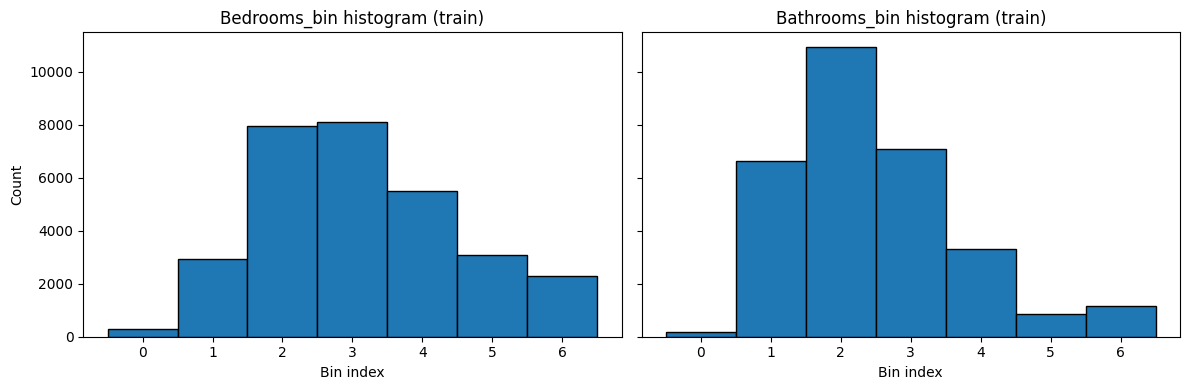

In [45]:
# Visualize the training-set distributions of the new bedroom/bathroom bins.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, ["Bedrooms_bin", "Bathrooms_bin"]):
    vals = X_train[col].dropna().astype(int)
    lo, hi = vals.min(), vals.max()
    edges = np.arange(lo - 0.5, hi + 1.5, 1)

    ax.hist(vals, bins=edges, edgecolor="black")
    ax.set_xticks(np.arange(lo, hi + 1))
    ax.set_xlabel("Bin index")
    ax.set_title(f"{col} histogram (train)")

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [49]:
# Bin latitude/longitude using training-derived quantile edges so we can cross
# them as a proxy for neighborhood/location effects.
for col in ["Latitude", "Longitude"]:
    _, bin_edges = pd.qcut(
        X_train[col], q=30, labels=False, retbins=True, duplicates="drop"
    )
    bin_edges = np.unique(bin_edges)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    X_train[f"{col}_bin"] = pd.cut(
        X_train[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_val[f"{col}_bin"] = pd.cut(
        X_val[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")
    X_test[f"{col}_bin"] = pd.cut(
        X_test[col], bins=bin_edges, labels=False, include_lowest=True
    ).astype("int64")

### Review split sizes

The dataset has now been partitioned into **training**, **validation**, and **test** sets.
The validation set is used during model development and tuning, while the test set is kept as a final holdout for unbiased evaluation.

In [42]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "pct_of_total": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
        "price_mean": [y_train.mean(), y_val.mean(), y_test.mean()],
        "price_median": [y_train.median(), y_val.median(), y_test.median()],
        "price_min": [y_train.min(), y_val.min(), y_test.min()],
        "price_max": [y_train.max(), y_val.max(), y_test.max()],
    }
)

split_summary["pct_of_total"] = split_summary["pct_of_total"].map(lambda v: f"{v:.1%}")
display(split_summary)


,split,rows,pct_of_total,price_mean,price_median,price_min,price_max
0,train,30172,70.0%,1072216.875,685400.0,50000.0,32000000.0
1,validation,6466,15.0%,1070186.750,686000.0,50000.0,58800000.0
2,test,6466,15.0%,1068150.750,686200.0,50000.0,49800000.0


### Final split analysis

We used a simple **train/validation/test holdout split** stratified on **price quantile bins**. This approach was appropriate because the dataset is fairly large at about **43,000 rows**, so each partition still contains plenty of observations across the range of home prices.

We did not use full cross-validation because it would add substantial computational cost while offering limited practical benefit for a dataset of this size. We also did not rely on repeated shuffle splits, since a single stratified holdout already gives a representative spread of price points in each partition and is easier to explain and reproduce.

In [61]:
# Now set up the 5 crossed features we want to create for the wide branch of our model.
cross_pairs = [
    ("City", "Property_Type"),
    ("City", "Square_Footage_bin"),
    ("Province", "Property_Type"),
    ("Bedrooms_bin", "Bathrooms_bin"),
    ("Latitude_bin", "Longitude_bin"),
]

# Compute data-driven crossing dimensions.
# We size each hash space from observed pair cardinality, capped by theoretical max.
rows = []
for a, b in cross_pairs:
    n_a = X_train[a].nunique(dropna=True)
    n_b = X_train[b].nunique(dropna=True)
    theoretical_max = int(n_a * n_b)
    observed_pairs = int(X_train[[a, b]].drop_duplicates().shape[0])

    suggested_dim = int(min(theoretical_max, max(32, np.ceil(observed_pairs * 1.5))))

    rows.append(
        {
            "pair": (a, b),
            "n_unique_a": int(n_a),
            "n_unique_b": int(n_b),
            "theoretical_max": theoretical_max,
            "observed_pairs": observed_pairs,
            "selected_crossing_dim": suggested_dim,
        }
    )

cross_stats = pd.DataFrame(rows)
display(cross_stats)

# Keys match cross_pairs and are used by FeatureSpace.cross below.
cross_dims = {
    row["pair"]: int(row["selected_crossing_dim"])
    for _, row in cross_stats.iterrows()
}

print("selected cross_dims =")
for k, v in cross_dims.items():
    print(f"  {k}: {v}")

,pair,n_unique_a,n_unique_b,theoretical_max,observed_pairs,selected_crossing_dim
0,"(City, Property_Type)",2633,4,10532,3059,4589
1,"(City, Square_Footage_bin)",2633,20,52660,7550,11325
2,"(Province, Property_Type)",11,4,44,37,44
3,"(Bedrooms_bin, Bathrooms_bin)",7,7,49,47,49
4,"(Latitude_bin, Longitude_bin)",30,30,900,382,573


selected cross_dims =
  ('City', 'Property_Type'): 4589
  ('City', 'Square_Footage_bin'): 11325
  ('Province', 'Property_Type'): 44
  ('Bedrooms_bin', 'Bathrooms_bin'): 49
  ('Latitude_bin', 'Longitude_bin'): 573


### Cross-pairing explanation

We selected crossed features, for the wide branch, where we believed the **combination** of two variables
would carry more pricing information than either variable alone.

- **City × Property Type:** the value of a condo, townhome, or single-family home can differ substantially from city to city.
- **City × Square Footage bin:** the effect of home size changes across markets, since a larger home
  in a high-cost city might show a premium vs a similarly sized home elsewhere.
- **Province × Property Type:** there might be broader regional pricing differences across provinces.
- **Bedrooms bin × Bathrooms bin:** these jointly describe the functional layout of a home BETTER
  than either count in isolation.
- **Latitude bin × Longitude bin:** TOGETHER these act as a neighborhood-level location,
  which is especially important in housing data where price is heavily influenced by location.

We limited crossings to this small set of pairs so the model might capture meaningful interactions
without creating an unnecessarily large or noisy feature space.

#### How many Crossed Feature dimensions?

For the hashed crossing DIMENSIONS, we chose a value between the observed number of unique pairings
in the training data and the theoretical maximum possible number of pairings.
In practice, we used about **1.5 × the observed number of pairs**, capped by the theoretical maximum.

The final dimensions seems reasonable, but two of them are quite large. It will be interesting to see
how this affects the model, and any embeddings.

We wondered how these dimensions were used/populated for each crossed pair. These
crossed feature pairs are implemented using Keras feature crosses, which hash each
observed pair into a fixed integer space. These hashed cross-indices are then
passed through embedding layers so the network can learn compact representations
of thee important feature interactions.

In [121]:
# From 10a. Keras Wide and Deep as TFData.ipynb.
#
# Finally, set up the Keras preprocessing layers for the crossed features, categorical features,
# and numeric features.
#
# Use the Keras FeatureSpace utility to manage all of the preprocessing for us,
# including learning normalization parameters from the training data and applying
# the same transformations to the test data.

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

from sklearn import metrics as mt
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)


2.19.0
3.13.2


In [65]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

from tensorflow.keras.layers import Dense, Activation, Input, Dropout
from tensorflow.keras.layers import Embedding, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

from tensorflow.keras.utils import FeatureSpace

# Crossing columns together 
feature_space = FeatureSpace(
    features={
        # Categorical feature encoded as string. 11 of these.
        "Balcony":       FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "City":          FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Fireplace":     FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Garage":        FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Garden":        FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Parking":       FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Pool":          FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Property_Type": FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Province":      FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Sewer":         FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Waterfront":    FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),

        # Our discretized numeric features that we want to treat as categorical for crossing and
        # also in the deep branch.  6 of these.
        "Acreage_bin":        FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Bathrooms_bin":      FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Bedrooms_bin":       FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Latitude_bin":       FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Longitude_bin":      FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Square_Footage_bin": FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        
        # Numerical features to normalize (normalization will be learned)
        # learns the mean, variance, and if to invert (3 parameters)
        # 4 of these.
        "Bathrooms": FeatureSpace.float_normalized(),
        "Bedrooms":  FeatureSpace.float_normalized(),
        "Latitude":  FeatureSpace.float_normalized(),
        "Longitude": FeatureSpace.float_normalized(),
    },
    # Specify feature cross with a custom crossing dim
    crosses=[
        FeatureSpace.cross(
            feature_names=pair,
            crossing_dim=cross_dims[pair],
            output_mode="int",
        )
        for pair in cross_pairs
    ],
    output_mode="dict",
)

### Set up Tensorflow tf.data

In this section, we build TensorFlow datasets that feed tensors to the model.

We convert the split pandas dataframes into TensorFlow input pipelines for:
* training
* validation
* testing

Each dataset includes a dictionary of input features and a target variable, Price for each modeled input.
They become `tf.data` datasets. These pipelines supply batches of feature tensors and target values
during model training and evaluation. We shuffle only the training data, and the runtime
prefetches batches for performance.

In [66]:
# Now create tf.data datasets for training, validation, and final holdout testing.
batch_size = 256

ds_train = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train.values))
ds_train = ds_train.shuffle(len(X_train), seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((dict(X_val), y_val.values))
ds_val = ds_val.batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_test = tf.data.Dataset.from_tensor_slices((dict(X_test), y_test.values))
ds_test = ds_test.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [67]:
# Learn preprocessing parameters from the training data only, then apply the
# exact same transforms to validation and test.
train_ds_with_no_labels = ds_train.map(lambda x, _: x)

# ADAPT is the key method that learns normalization parameters
# for numeric features and learns the unique values for
# categorical features (which are needed for hashing and crossing).
# We only adapt on the training data so that the validation and test data remain unseen.
feature_space.adapt(train_ds_with_no_labels)

preprocessed_ds_train = ds_train.map(
    lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

preprocessed_ds_val = ds_val.map(
    lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

preprocessed_ds_test = ds_test.map(
    lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


### Set up Embeddings

In [69]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

# Features are encoded as integers and normalized floats.
# We use embeddings to deal with the integer-encoded features
# as if they were one-hot encoded, which allows us to use them
# in the wide branch of our model without blowing up the dimensionality.

def setup_embedding_from_encoding_crossing(encoded_features, feature_space, col_name):
    # get the size of the feature
    x = encoded_features[col_name]
    # get the size of the feature
    N = feature_space.crossers[col_name].num_bins
    N_embed = int(np.sqrt(N))
    print(f'Crossing: {col_name} from {N} OHE to {N_embed} features.')
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_embed, 
                  name=col_name+'_embed')(x)
    return  Flatten()(x) # get rid of that pesky extra dimension (for time of embedding)

def setup_embedding_from_encoding_categorical(encoded_features, feature_space, col_name):
    # get the size of the feature
    x = encoded_features[col_name]
    # get the size of the feature
    N = len(feature_space.preprocessors[col_name].get_vocabulary())
    N_embed = int(np.sqrt(N))
    
    print(f'Category Embed: {col_name} from {N} OHE to {N_embed} features.')
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_embed, 
                  name=col_name+'_embed')(x)
    return Flatten()(x) # get rid of that pesky extra dimension (for time of embedding)

dict_inputs = feature_space.get_inputs() # need to use unprocessed features here, to gain access to each output
encoded_feature_tensors = feature_space.get_encoded_features() # these features have been encoded

# Build explicitly named encoded inputs so dict keys match tensor names exactly.
encoded_features = {
    col: keras.Input(
        shape=tensor.shape[1:],
        dtype=tensor.dtype,
        name=col
    )
    for col, tensor in encoded_feature_tensors.items()
}

# Only keep numeric headers that are still present after discretization.
numeric_deep_headers = [col for col in continuous_numeric_headers if col in encoded_features]

# we need to create separate lists for each branch: the wide branch will
# use the crossed features, and the deep branch will use the numeric
# features and categorical features (after embedding).
crossed_outputs = []

# for each crossed variable, make an embedding
for col in feature_space.crossers.keys():
    x = setup_embedding_from_encoding_crossing(encoded_features, feature_space, col)
    
    # save these outputs in list to concatenate later
    crossed_outputs.append(x)

# now concatenate the outputs and add a fully connected layer
wide_branch = Concatenate(name='wide_concat')(crossed_outputs)

# reset this input branch
all_deep_branch_outputs = []

# for each numeric variable, just add it in after embedding
for col in numeric_deep_headers:
    x = encoded_features[col]
    all_deep_branch_outputs.append(x)
    
# for each categorical variable
for col in categorical_headers:
    # get the output tensor from ebedding layer
    x = setup_embedding_from_encoding_categorical(encoded_features,feature_space, col)
    
    # save these outputs in list to concatenate later
    all_deep_branch_outputs.append(x)

# Ensure every declared encoded input is connected to the graph.
used_feature_keys = set(feature_space.crossers.keys()) | set(numeric_deep_headers) | set(categorical_headers)
for col in sorted(encoded_features.keys()):
    if col not in used_feature_keys:
        all_deep_branch_outputs.append(encoded_features[col])

Crossing: City_X_Property_Type from 4589 OHE to 67 features.
Crossing: City_X_Square_Footage_bin from 11325 OHE to 106 features.
Crossing: Province_X_Property_Type from 44 OHE to 6 features.
Crossing: Bedrooms_bin_X_Bathrooms_bin from 49 OHE to 7 features.
Crossing: Latitude_bin_X_Longitude_bin from 573 OHE to 23 features.
Category Embed: Balcony from 3 OHE to 1 features.
Category Embed: City from 2634 OHE to 51 features.
Category Embed: Fireplace from 3 OHE to 1 features.
Category Embed: Garage from 3 OHE to 1 features.
Category Embed: Garden from 3 OHE to 1 features.
Category Embed: Parking from 3 OHE to 1 features.
Category Embed: Pool from 3 OHE to 1 features.
Category Embed: Property_Type from 5 OHE to 2 features.
Category Embed: Province from 12 OHE to 3 features.
Category Embed: Sewer from 6 OHE to 2 features.
Category Embed: Waterfront from 3 OHE to 1 features.


### Analysis

This is pretty cool. We now have a number of interesting features, including
these crossed features which may be more useful signals for Price.

Notice how the dimensionality for the OHE features is significantly
lower than it would have been.

## Choosing our Metrics for Algorithm performance

We will evaluate our regression model with **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. MAE gives an human-visible
measure of the average dollar error in the predictions, while RMSE shows a larger penalty on large mistakes.
This is important in housing-price prediction, where very large overestimates or underestimates can be especially costly,
to buyers and sellers.

We do **not** use `accuracy`, `precision`, or `recall` because those metrics are designed for **classification**
problems with discrete class labels, whereas our target is a continuous numeric price.

In addition to MAE and RMSE, we will use a **Bland–Altman plot** to visualize agreement
between the predicted prices and the true prices. This plot helps show whether the
model tends to overpredict or underpredict and whether the prediction errors
become larger at certain price ranges. That makes it a useful complement to
summary metrics, since it reveals patterns in the residuals that a single number alone might hide.

## Modeling

### Model 1: wide and deep with crossed-features

This is a wide and deep model. The wide branch uses the crossed features, which are
integer-coded and passed through embedding layers.

The deep branch uses the continuous numeric features, and the categorical features,
also through the embedding layers. It's a 3 layer model with 50, 25, and 10 neurons.

To be clear, the crossed-feature embeddings feed the wide branch while the categorical
feature embeddings feed the deep branch.

The two branches are merged using concatenation and the final output layer is a dense
layer with linear activation. We don't use sigmoid since this is a regression task.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Balcony             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Property_Type       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Province            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sewer (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Waterfront          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Balcony_embed       │ (None, 1, 1)      │          3 │ Balcony[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City_embed          │ (None, 1, 51)     │    134,334 │ City[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace_embed     │ (None, 1, 1)      │          3 │ Fireplace[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage_embed        │ (None, 1, 1)      │          3 │ Garage[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden_embed        │ (None, 1, 1)      │          3 │ Garden[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking_embed       │ (None, 1, 1)      │          3 │ Parking[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_embed          │ (None, 1, 1)      │          3 │ Pool[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,661,667 (6.34 MB)

 Trainable params: 1,661,667 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

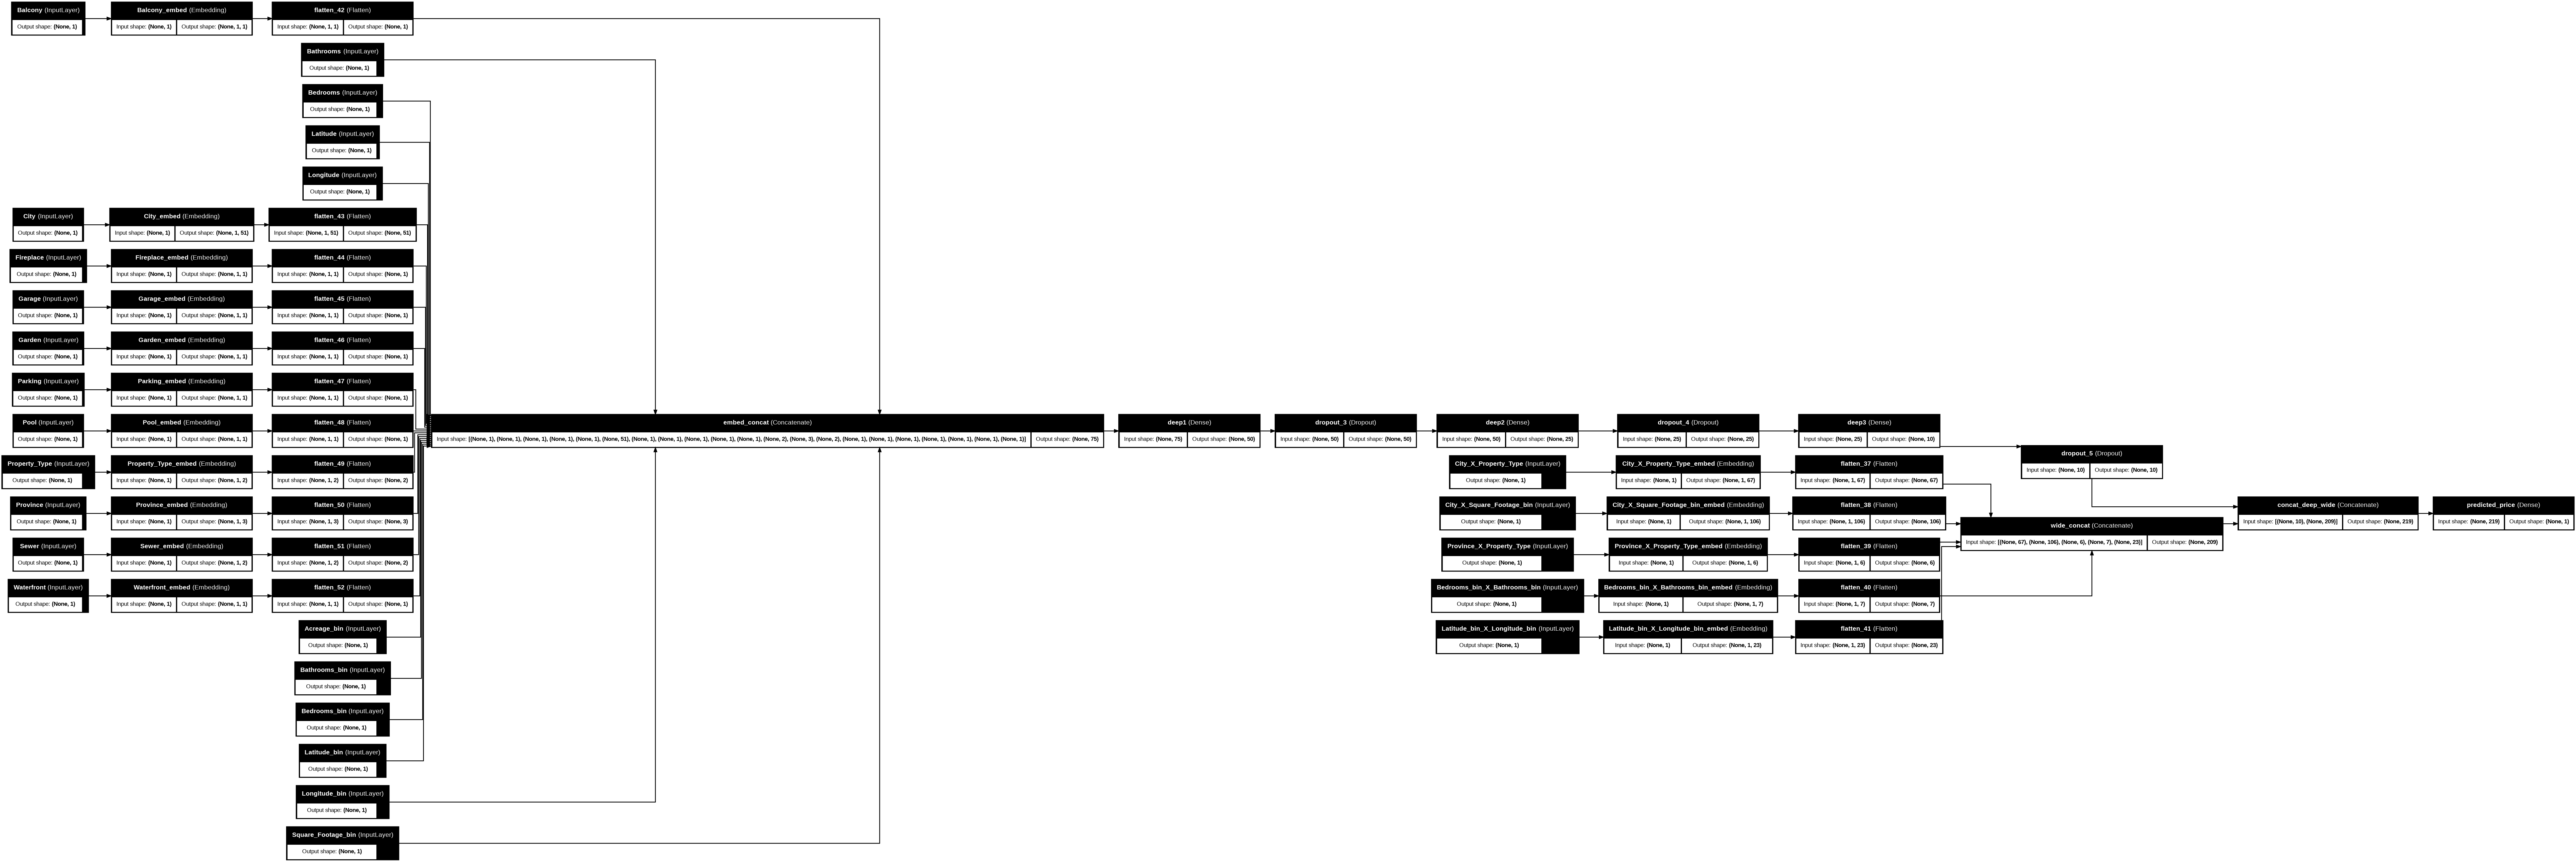

In [70]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

# merge the deep branches together
deep_branch = Concatenate(name='embed_concat')(all_deep_branch_outputs)
deep_branch = Dense(units=50,activation='relu', name='deep1')(deep_branch)
deep_branch = Dropout(0.6)(deep_branch)
deep_branch = Dense(units=25,activation='relu', name='deep2')(deep_branch)
deep_branch = Dropout(0.4)(deep_branch)
deep_branch = Dense(units=10,activation='relu', name='deep3')(deep_branch)
deep_branch = Dropout(0.2)(deep_branch)
    
# merge the deep and wide branch
final_branch = Concatenate(name='concat_deep_wide')([deep_branch, wide_branch])

# Now final output for regression uses linear activation, not sigmoid.
final_branch = Dense(units=1, activation='linear',
                     name='predicted_price')(final_branch)

# encoded features input, fast
training_model = keras.Model(inputs=encoded_features, outputs=final_branch)

# Uses MSE loss for regression, and tracks MAE and RMSE as metrics,
# whereas before this used binary crossentropy loss and accuracy metrics for classification.
training_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
 )

training_model.summary()

# non-encoded: use the encoded tensors that are already connected to dict_inputs
inference_output = training_model(encoded_feature_tensors)
inference_model = keras.Model(inputs=dict_inputs, outputs=inference_output)
inference_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
 )


plot_model(
    training_model, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

In [71]:
# Re-compile before fit to ensure a fresh optimizer state after graph/name edits.
# Tune against the validation set; keep the test set as a final holdout only.
training_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse",
    metrics=[
        "mae",
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ]
)

history = training_model.fit(
    preprocessed_ds_train,
    epochs=30,
    validation_data=preprocessed_ds_val,
    verbose=2,
)

Epoch 1/30
118/118 - 11s - 97ms/step - loss: 3219987103744.0000 - mae: 1072102.1250 - rmse: 1794432.2500 - val_loss: 3402417569792.0000 - val_mae: 1069443.2500 - val_rmse: 1844564.3750
Epoch 2/30
118/118 - 5s - 40ms/step - loss: 3188142374912.0000 - mae: 1058483.1250 - rmse: 1785537.0000 - val_loss: 3288867012608.0000 - val_mae: 1020494.3750 - val_rmse: 1813523.3750
Epoch 3/30
118/118 - 3s - 29ms/step - loss: 2786792570880.0000 - mae: 880195.2500 - rmse: 1669368.8750 - val_loss: 2491485782016.0000 - val_mae: 667611.5000 - val_rmse: 1578444.1250
Epoch 4/30
118/118 - 4s - 31ms/step - loss: 2046169710592.0000 - mae: 665623.8750 - rmse: 1430443.8750 - val_loss: 2004371111936.0000 - val_mae: 632239.0000 - val_rmse: 1415758.1250
Epoch 5/30
118/118 - 3s - 24ms/step - loss: 1881990365184.0000 - mae: 685170.3125 - rmse: 1371856.5000 - val_loss: 1933086031872.0000 - val_mae: 614035.6250 - val_rmse: 1390354.6250
Epoch 6/30
118/118 - 3s - 24ms/step - loss: 1837256146944.0000 - mae: 665632.4375 - r

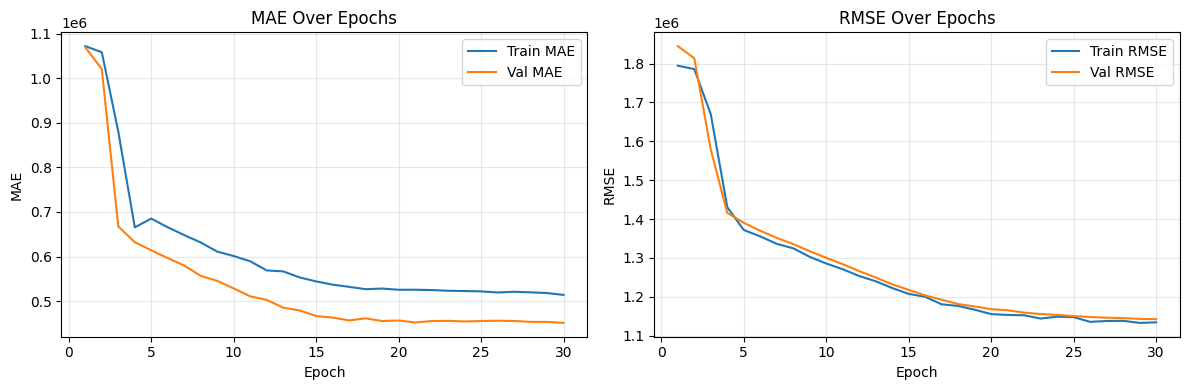

In [72]:
from matplotlib import pyplot as plt

%matplotlib inline

epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE over epochs
axes[0].plot(epochs, history.history["mae"], label="Train MAE")
axes[0].plot(epochs, history.history["val_mae"], label="Val MAE")
axes[0].set_title("MAE Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE over epochs
axes[1].plot(epochs, history.history["rmse"], label="Train RMSE")
axes[1].plot(epochs, history.history["val_rmse"], label="Val RMSE")
axes[1].set_title("RMSE Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Validation-set metrics:
  mae: 451139.9375
  rmse: 1142488.1250

Holdout metrics - training_model path:
  mae: 456960.1250
  rmse: 1158565.8750

Holdout metrics - inference_model path:
  mae: 456960.1250
  rmse: 1158565.8750


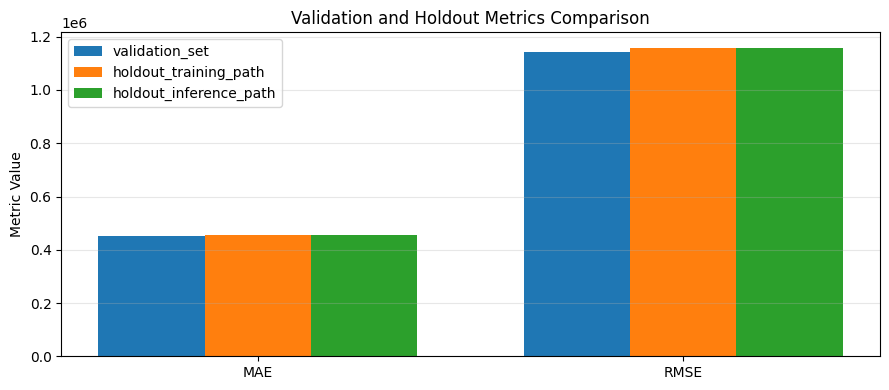

In [84]:
# Compare validation and holdout performance for the wide/deep model.
# We can keep this simple by using the final validation metrics already stored in
# the training history, then comparing those against the holdout test metrics.

validation_results = {
    "mae": float(history.history["val_mae"][-1]),
    "rmse": float(history.history["val_rmse"][-1]),
}

# Holdout test metrics using both model entry paths.
y_true = y_test.to_numpy().reshape(-1)
y_pred_train = training_model.predict(preprocessed_ds_test, verbose=0).reshape(-1)

input_name_order = [tensor.name.split(":")[0] for tensor in inference_model.inputs]
X_test_for_inference = []
for name in input_name_order:
    values = X_test[name].to_numpy().reshape(-1, 1)

    if name in categorical_headers:
        tensor = tf.convert_to_tensor(values.astype(str), dtype=tf.string)
    elif name.endswith("_bin"):
        tensor = tf.convert_to_tensor(values, dtype=tf.int64)
    else:
        tensor = tf.convert_to_tensor(values, dtype=tf.float32)

    X_test_for_inference.append(tensor)

y_pred_infer = inference_model.predict(
    X_test_for_inference,
    batch_size=batch_size,
    verbose=0,
).reshape(-1)

train_results = {
    "mae": float(np.mean(np.abs(y_true - y_pred_train))),
    "rmse": float(np.sqrt(np.mean((y_true - y_pred_train) ** 2))),
}
infer_results = {
    "mae": float(np.mean(np.abs(y_true - y_pred_infer))),
    "rmse": float(np.sqrt(np.mean((y_true - y_pred_infer) ** 2))),
}

print("Validation-set metrics:")
for k, v in validation_results.items():
    print(f"  {k}: {v:.4f}")

print("\nHoldout metrics - training_model path:")
for k, v in train_results.items():
    print(f"  {k}: {v:.4f}")

print("\nHoldout metrics - inference_model path:")
for k, v in infer_results.items():
    print(f"  {k}: {v:.4f}")

# Plot MAE and RMSE comparison across all three result sets.
metrics_to_plot = ["mae", "rmse"]
x = np.arange(len(metrics_to_plot))
width = 0.25

val_vals = [validation_results[m] for m in metrics_to_plot]
train_vals = [train_results[m] for m in metrics_to_plot]
infer_vals = [infer_results[m] for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width, val_vals, width, label="validation_set")
ax.bar(x, train_vals, width, label="holdout_training_path")
ax.bar(x + width, infer_vals, width, label="holdout_inference_path")

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("Metric Value")
ax.set_title("Validation and Holdout Metrics Comparison")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Model 1: Visualizations


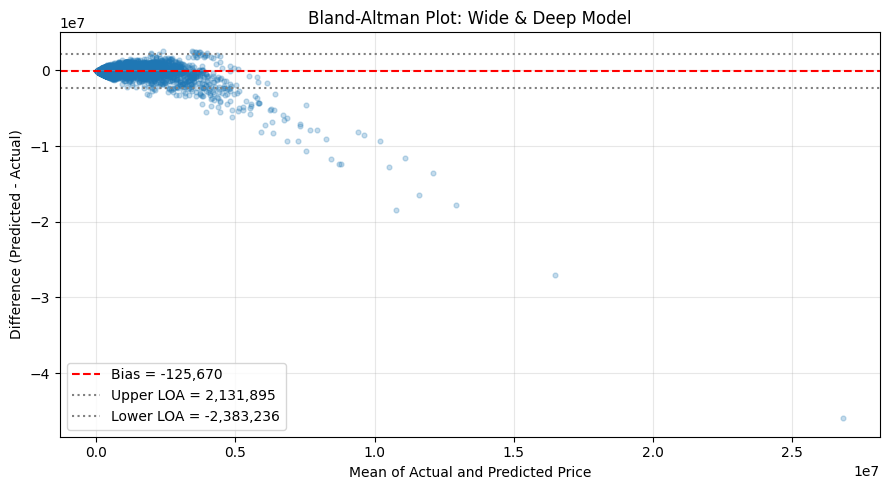

Bias: -125,670.44
Upper limit of agreement: 2,131,894.75
Lower limit of agreement: -2,383,235.75


In [85]:
# Bland-Altman plot for the current regression model.
# We define the difference as (predicted - actual) so positive values mean
# overprediction and negative values mean underprediction, matching the
# percent-error plot sign convention.
actual = y_true.reshape(-1)
predicted = y_pred_infer.reshape(-1)

mean_vals = (actual + predicted) / 2
diff_vals = predicted - actual

bias = diff_vals.mean()
sd = diff_vals.std(ddof=1)
loa_upper = bias + 1.96 * sd
loa_lower = bias - 1.96 * sd

plt.figure(figsize=(9, 5))
plt.scatter(mean_vals, diff_vals, alpha=0.25, s=12)
plt.axhline(bias, color="red", linestyle="--", label=f"Bias = {bias:,.0f}")
plt.axhline(loa_upper, color="gray", linestyle=":", label=f"Upper LOA = {loa_upper:,.0f}")
plt.axhline(loa_lower, color="gray", linestyle=":", label=f"Lower LOA = {loa_lower:,.0f}")

plt.title("Bland-Altman Plot: Wide & Deep Model")
plt.xlabel("Mean of Actual and Predicted Price")
plt.ylabel("Difference (Predicted - Actual)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Bias: {bias:,.2f}")
print(f"Upper limit of agreement: {loa_upper:,.2f}")
print(f"Lower limit of agreement: {loa_lower:,.2f}")

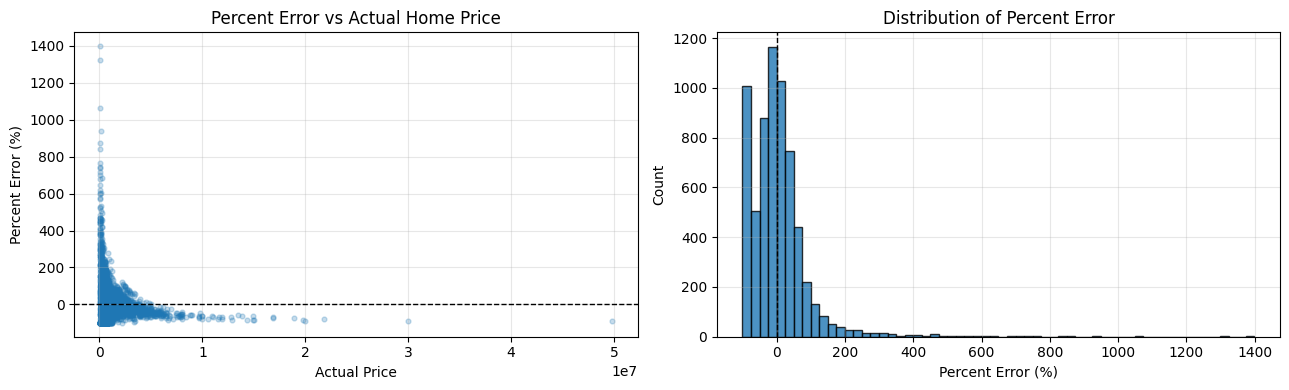

Median absolute percent error: 39.82%
Mean absolute percent error: 56.11%


In [86]:
# Additional diagnostic: percent error relative to the actual home price.
# Here we define percent error so positive values mean the model OVER-predicted
# relative to the actual price, and negative values mean it UNDER-predicted.
percent_error = 100.0 * (y_pred_infer - y_true) / np.maximum(np.abs(y_true), 1e-8)
abs_percent_error = np.abs(percent_error)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatterplot of percent error vs actual price.
axes[0].scatter(y_true, percent_error, alpha=0.25, s=12)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Percent Error vs Actual Home Price')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Percent Error (%)')
axes[0].grid(True, alpha=0.3)

# Histogram of percent error to show spread and skew.
axes[1].hist(percent_error, bins=60, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Percent Error')
axes[1].set_xlabel('Percent Error (%)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Median absolute percent error: {np.median(abs_percent_error):.2f}%")
print(f"Mean absolute percent error: {np.mean(abs_percent_error):.2f}%")

#### Model 1: Explanation

The **Bland–Altman** plot for Model 1 shows the agreement between predicted and actual
home prices by plotting residual error against the mean price.
The `y-axis` shows the residual error, the `predicted - actual` difference.
The `x-axis` shows the avg of the actual and predicted values, higher priced homes further right.

This model shows predictions which are reasonably centered around the true values, especially
for the lower priced homes, under $500k. This plot **does** show that this model degrades as
home price gets larger. Two observations:
* there's a cluster of overpredicted prices in the $400k-$500k range
* as prices increase >$500k the model tends to underpredict more and more, at a linear rate

The limits of agreement (LOA) are relatively wide, indicating substantial variability in
prediction error. This suggests that while the model may capture overall pricing patterns,
it can still overestimate or underestimate individual homes by a large amount,
especially at the higher end of the market.

In general, we're disappointed that our residuals aren't smaller.

Looking at some **percent error** plots, the histogram seems to show we're
overall underpredicting more than overpredicting.
But, the **percent error** scatter plot suggests we're overpredicting many lower priced homes, 
while we're generally underpredicting higher priced homes. We need to improve this.

### Model 2

For model 2, we vary Model 1. We're going to adjust to 5 layers,
and we'll adjust neuron counts to: 128, 64, 32, 16, 8. This will add
a bit more capacity/complexity to the model for fitting. We'll also
try a slightly less aggressive dropout. This dropout might be forcing
us to underfit a bit.

One thing we noticed is this model was still converging at 30 epochs.
So, we increased the training to 50 epochs. And, it still didn't seem
to have plateaued. So we increased to 75 epochs.

In [97]:
# Model 2 - wide and deep with 5 layers in the deep branch instead of 3,
# and with more units in each layer.
# We reuse the same preprocessing, crossed features, and train/validation/test
# datasets as Model 1, but build a fresh set of trainable layers so Model 1
# is left unchanged.

from tensorflow.keras.layers import Dense, Dropout, Embedding, Concatenate, Flatten
from tensorflow.keras.models import Model


def build_model_2(encoded_feature_tensors, feature_space, categorical_headers, numeric_deep_headers):
    encoded_inputs_m2 = {
        col: keras.Input(
            shape=tensor.shape[1:],
            dtype=tensor.dtype,
            name=col,
        )
        for col, tensor in encoded_feature_tensors.items()
    }

    def embed_cross_m2(col_name):
        x = encoded_inputs_m2[col_name]
        n_bins = feature_space.crossers[col_name].num_bins
        n_embed = int(np.ceil(np.sqrt(n_bins)))
        x = Embedding(
            input_dim=n_bins,
            output_dim=n_embed,
            name=f"{col_name}_embed_m2",
        )(x)
        return Flatten()(x)

    def embed_cat_m2(col_name):
        x = encoded_inputs_m2[col_name]
        n_vocab = len(feature_space.preprocessors[col_name].get_vocabulary())
        n_embed = int(np.ceil(np.sqrt(n_vocab)))
        x = Embedding(
            input_dim=n_vocab,
            output_dim=n_embed,
            name=f"{col_name}_embed_m2",
        )(x)
        return Flatten()(x)

    crossed_outputs_m2 = [embed_cross_m2(col) for col in feature_space.crossers.keys()]
    wide_branch_m2 = Concatenate(name="wide_concat_m2")(crossed_outputs_m2)

    deep_parts_m2 = []
    for col in numeric_deep_headers:
        if col in encoded_inputs_m2:
            deep_parts_m2.append(encoded_inputs_m2[col])

    for col in categorical_headers:
        deep_parts_m2.append(embed_cat_m2(col))

    used_feature_keys = set(feature_space.crossers.keys()) | set(numeric_deep_headers) | set(categorical_headers)
    for col in sorted(encoded_inputs_m2.keys()):
        if col not in used_feature_keys:
            deep_parts_m2.append(encoded_inputs_m2[col])

    deep_branch_m2 = Concatenate(name="embed_concat_m2")(deep_parts_m2)
    deep_branch_m2 = Dense(128, activation="relu", name="deep_m2_1")(deep_branch_m2)
    deep_branch_m2 = Dropout(0.20, name="dropout_m2_1")(deep_branch_m2)
    deep_branch_m2 = Dense(64, activation="relu", name="deep_m2_2")(deep_branch_m2)
    deep_branch_m2 = Dropout(0.15, name="dropout_m2_2")(deep_branch_m2)
    deep_branch_m2 = Dense(32, activation="relu", name="deep_m2_3")(deep_branch_m2)
    deep_branch_m2 = Dropout(0.10, name="dropout_m2_3")(deep_branch_m2)
    deep_branch_m2 = Dense(16, activation="relu", name="deep_m2_4")(deep_branch_m2)
    deep_branch_m2 = Dropout(0.10, name="dropout_m2_4")(deep_branch_m2)
    deep_branch_m2 = Dense(8, activation="relu", name="deep_m2_5")(deep_branch_m2)
    deep_branch_m2 = Dropout(0.05, name="dropout_m2_5")(deep_branch_m2)

    final_branch_m2 = Concatenate(name="concat_deep_wide_m2")([deep_branch_m2, wide_branch_m2])
    output_m2 = Dense(1, activation="linear", name="predicted_price_m2")(final_branch_m2)

    training_model_m2 = Model(inputs=encoded_inputs_m2, outputs=output_m2, name="wide_deep_model_2")
    training_model_m2.compile(
        optimizer=keras.optimizers.Adam(),
        loss="mse",
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )

    inference_output_m2 = training_model_m2(encoded_feature_tensors)
    inference_model_m2 = Model(inputs=dict_inputs, outputs=inference_output_m2, name="wide_deep_model_2_inference")
    inference_model_m2.compile(
        optimizer=keras.optimizers.Adam(),
        loss="mse",
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )

    return training_model_m2, inference_model_m2


training_model_m2, inference_model_m2 = build_model_2(
    encoded_feature_tensors,
    feature_space,
    categorical_headers,
    numeric_deep_headers,
)

training_model_m2.summary()

history_m2 = training_model_m2.fit(
    preprocessed_ds_train,
    epochs=75,  # 30 -> 50 -> 75 epochs to give this larger model more time to learn
    validation_data=preprocessed_ds_val,
    verbose=2,
)

m2_test_preds = training_model_m2.predict(preprocessed_ds_test, verbose=0).reshape(-1)
m2_test_mae = float(np.mean(np.abs(y_test.to_numpy().reshape(-1) - m2_test_preds)))
m2_test_rmse = float(np.sqrt(np.mean((y_test.to_numpy().reshape(-1) - m2_test_preds) ** 2)))

print(f"Model 2 holdout MAE: {m2_test_mae:,.2f}")
print(f"Model 2 holdout RMSE: {m2_test_rmse:,.2f}")

Model: "wide_deep_model_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Balcony             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Property_Type       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Province            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sewer (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Waterfront          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Balcony_embed_m2    │ (None, 1, 2)      │          6 │ Balcony[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City_embed_m2       │ (None, 1, 52)     │    136,968 │ City[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace_embed_m2  │ (None, 1, 2)      │          6 │ Fireplace[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage_embed_m2     │ (None, 1, 2)      │          6 │ Garage[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden_embed_m2     │ (None, 1, 2)      │          6 │ Garden[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking_embed_m2    │ (None, 1, 2)      │          6 │ Parking[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_embed_m2       │ (None, 1, 2)      │          6 │ Pool[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,697,679 (6.48 MB)

 Trainable params: 1,697,679 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/75
118/118 - 10s - 85ms/step - loss: 3209957998592.0000 - mae: 1067597.1250 - rmse: 1791635.6250 - val_loss: 3305117581312.0000 - val_mae: 1026465.1875 - val_rmse: 1817998.2500
Epoch 2/75
118/118 - 4s - 31ms/step - loss: 2233653526528.0000 - mae: 770839.0625 - rmse: 1494541.2500 - val_loss: 1967680258048.0000 - val_mae: 660670.6875 - val_rmse: 1402740.2500
Epoch 3/75
118/118 - 3s - 26ms/step - loss: 1743395880960.0000 - mae: 661472.6250 - rmse: 1320377.1250 - val_loss: 1769815408640.0000 - val_mae: 579014.5625 - val_rmse: 1330344.1250
Epoch 4/75
118/118 - 3s - 26ms/step - loss: 1545433907200.0000 - mae: 582193.8750 - rmse: 1243154.8750 - val_loss: 1581881884672.0000 - val_mae: 502966.5938 - val_rmse: 1257728.8750
Epoch 5/75
118/118 - 4s - 38ms/step - loss: 1360989913088.0000 - mae: 520363.4375 - rmse: 1166614.7500 - val_loss: 1401711230976.0000 - val_mae: 490143.6875 - val_rmse: 1183938.8750
Epoch 6/75
118/118 - 4s - 31ms/step - loss: 1220876959744.0000 - mae: 489977.1250 - rms

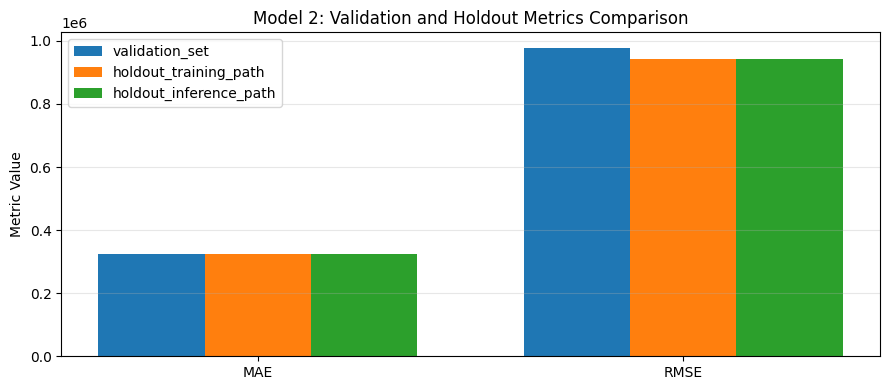

Model 2 validation metrics: {'mae': 323073.96875, 'rmse': 978173.8125}
Model 2 holdout metrics: {'mae': 324185.84375, 'rmse': 943985.0}


In [101]:
# Compare validation and holdout performance for Model 2.

validation_results_m2 = {
    "mae": float(history_m2.history["val_mae"][-1]),
    "rmse": float(history_m2.history["val_rmse"][-1]),
}

y_true_m2 = y_test.to_numpy().reshape(-1)
y_pred_m2 = training_model_m2.predict(preprocessed_ds_test, verbose=0).reshape(-1)

holdout_results_m2 = {
    "mae": float(np.mean(np.abs(y_true_m2 - y_pred_m2))),
    "rmse": float(np.sqrt(np.mean((y_true_m2 - y_pred_m2) ** 2))),
}

# In this notebook the training-path and inference-path predictions for Model 2
# are the same holdout evaluation, so we show all three bars for consistency
# with the Model 1 chart.
metrics_to_plot_m2 = ["mae", "rmse"]
x = np.arange(len(metrics_to_plot_m2))
width = 0.25

val_vals_m2 = [validation_results_m2[m] for m in metrics_to_plot_m2]
train_vals_m2 = [holdout_results_m2[m] for m in metrics_to_plot_m2]
infer_vals_m2 = [holdout_results_m2[m] for m in metrics_to_plot_m2]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width, val_vals_m2, width, label="validation_set")
ax.bar(x, train_vals_m2, width, label="holdout_training_path")
ax.bar(x + width, infer_vals_m2, width, label="holdout_inference_path")

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot_m2])
ax.set_ylabel("Metric Value")
ax.set_title("Model 2: Validation and Holdout Metrics Comparison")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Model 2 validation metrics:", validation_results_m2)
print("Model 2 holdout metrics:", holdout_results_m2)

#### Model 2: Visualizations

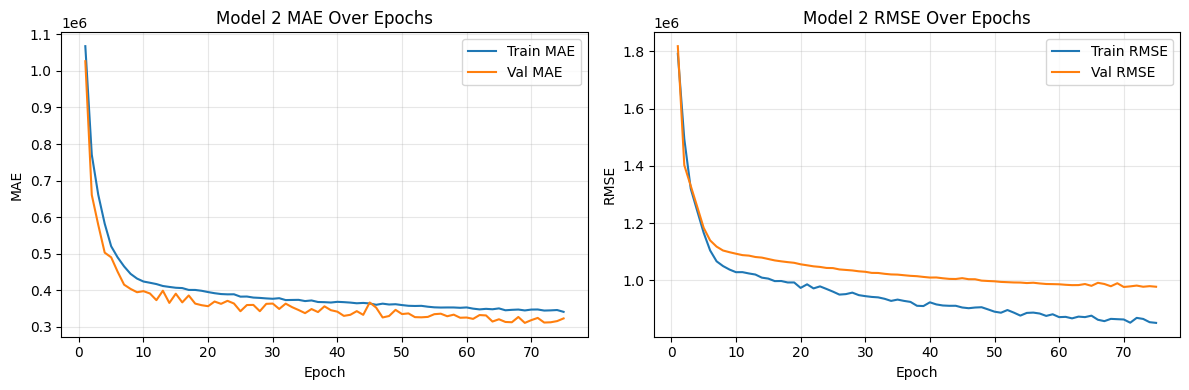

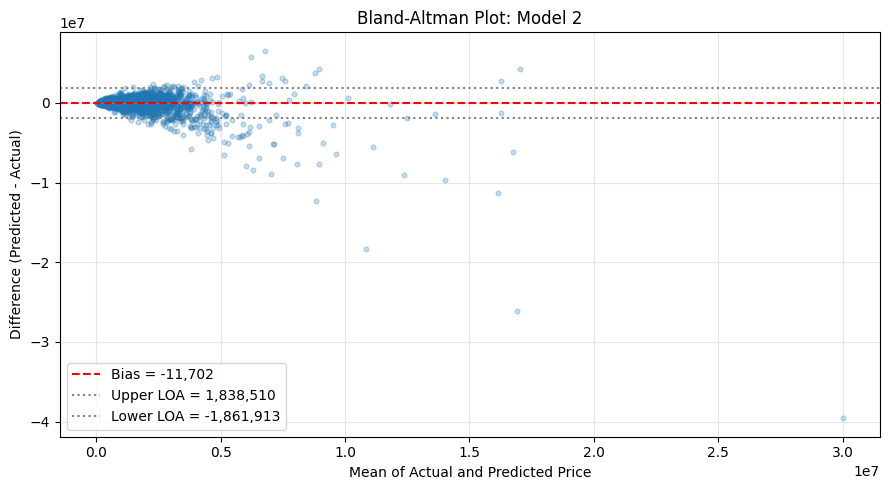

Model 2 Bias: -11,701.69
Model 2 Upper LOA: 1,838,510.00
Model 2 Lower LOA: -1,861,913.25


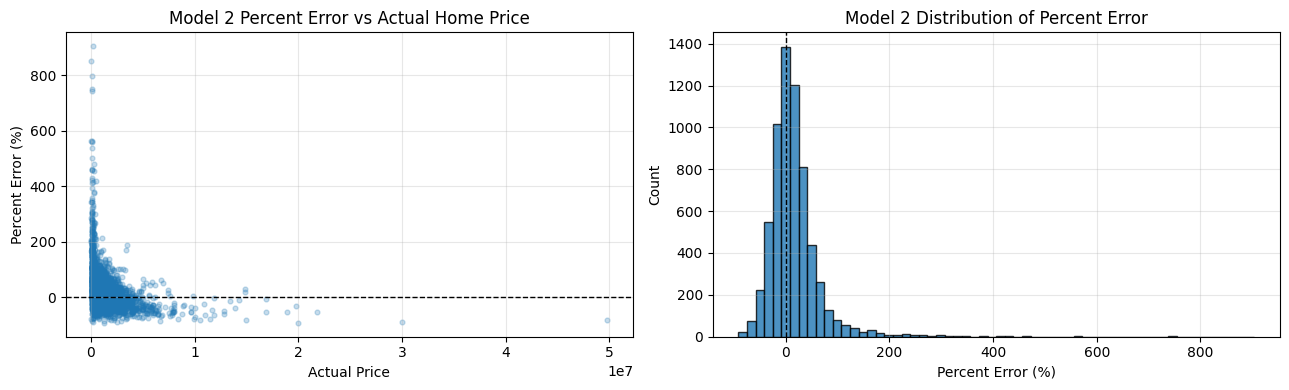

Model 2 Median absolute percent error: 21.43%
Model 2 Mean absolute percent error: 33.13%


In [102]:
# Model 2 visualizations: training curves, Bland-Altman, and percent-error diagnostics.

epochs_m2 = range(1, len(history_m2.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_m2, history_m2.history["mae"], label="Train MAE")
axes[0].plot(epochs_m2, history_m2.history["val_mae"], label="Val MAE")
axes[0].set_title("Model 2 MAE Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_m2, history_m2.history["rmse"], label="Train RMSE")
axes[1].plot(epochs_m2, history_m2.history["val_rmse"], label="Val RMSE")
axes[1].set_title("Model 2 RMSE Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bland-Altman plot for Model 2.
actual_m2 = y_test.to_numpy().reshape(-1)
predicted_m2 = m2_test_preds.reshape(-1)
mean_vals_m2 = (actual_m2 + predicted_m2) / 2
diff_vals_m2 = predicted_m2 - actual_m2

bias_m2 = diff_vals_m2.mean()
sd_m2 = diff_vals_m2.std(ddof=1)
loa_upper_m2 = bias_m2 + 1.96 * sd_m2
loa_lower_m2 = bias_m2 - 1.96 * sd_m2

plt.figure(figsize=(9, 5))
plt.scatter(mean_vals_m2, diff_vals_m2, alpha=0.25, s=12)
plt.axhline(bias_m2, color="red", linestyle="--", label=f"Bias = {bias_m2:,.0f}")
plt.axhline(loa_upper_m2, color="gray", linestyle=":", label=f"Upper LOA = {loa_upper_m2:,.0f}")
plt.axhline(loa_lower_m2, color="gray", linestyle=":", label=f"Lower LOA = {loa_lower_m2:,.0f}")
plt.title("Bland-Altman Plot: Model 2")
plt.xlabel("Mean of Actual and Predicted Price")
plt.ylabel("Difference (Predicted - Actual)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Model 2 Bias: {bias_m2:,.2f}")
print(f"Model 2 Upper LOA: {loa_upper_m2:,.2f}")
print(f"Model 2 Lower LOA: {loa_lower_m2:,.2f}")

# Percent-error diagnostics for Model 2.
percent_error_m2 = 100.0 * (predicted_m2 - actual_m2) / np.maximum(np.abs(actual_m2), 1e-8)
abs_percent_error_m2 = np.abs(percent_error_m2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(actual_m2, percent_error_m2, alpha=0.25, s=12)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Model 2 Percent Error vs Actual Home Price')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Percent Error (%)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(percent_error_m2, bins=60, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Model 2 Distribution of Percent Error')
axes[1].set_xlabel('Percent Error (%)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Model 2 Median absolute percent error: {np.median(abs_percent_error_m2):.2f}%")
print(f"Model 2 Mean absolute percent error: {np.mean(abs_percent_error_m2):.2f}%")

In [103]:
# Compare percent-error metrics for Model 1 vs Model 2.
percent_error_summary = pd.DataFrame(
    {
        "Model": ["Model 1", "Model 2"],
        "MAE": [
            train_results["mae"],
            m2_test_mae,
        ],
        "RMSE": [
            train_results["rmse"],
            m2_test_rmse,
        ],
        "Median Absolute Percent Error (%)": [
            np.median(abs_percent_error),
            np.median(abs_percent_error_m2),
        ],
        "Mean Absolute Percent Error (%)": [
            np.mean(abs_percent_error),
            np.mean(abs_percent_error_m2),
        ],
    }
)

percent_error_summary.iloc[:, 1:] = percent_error_summary.iloc[:, 1:].round(2)
display(percent_error_summary)

,Model,MAE,RMSE,Median Absolute Percent Error (%),Mean Absolute Percent Error (%)
0,Model 1,456960.12,1158565.88,39.82,56.110001
1,Model 2,324185.84,943985.00,21.43,33.130001


#### Model 2: Explanation

Model 2 improved on Model 1 because we made **four real architecture changes** to the deep branch:

1. We increased the depth from **3 hidden layers** to **5 hidden layers**.
2. We increased the number of neurons from **50, 25, and 10** in Model 1 to **128, 64, 32, 16, and 8** in Model 2.
3. We also used a **less aggressive dropout schedule**. Model 1 used dropout rates of **0.60, 0.40, and 0.20**, while Model 2 used **0.20, 0.15, 0.10, 0.10, and 0.05**.
4. We increased #epochs from 30 to 50 and finally to 75.

These changes gave the network more capacity to learn nonlinear pricing patterns
while also avoiding the heavier regularization that may have caused some
underfitting in Model 1.

One thing we noticed is the validation RMSE seems to plateau around epoch 60 while
training RMSE continues to decrease. This suggested to us that the model is now
overfitting, and we need to make different adjustments to improve the model performance.

### Model 3

Model 3 is simply a comparison of our wide and deep model vs a more traditional MLP model.
The easiest way to do this is to do the same 5 layer model as Model 2, but to remove the
wide branch.


In [105]:
# Model 3 - deep-only MLP baseline mirroring Model 2, but without the wide branch.
# This reuses the same deep-layer sizes, dropout schedule, and epoch count as Model 2
# so the comparison is focused on whether the wide branch helps.

cross_feature_names = list(feature_space.crossers.keys())
deep_only_feature_names = [k for k in encoded_feature_tensors.keys() if k not in cross_feature_names]

def strip_cross_features(x, y):
    return ({k: x[k] for k in deep_only_feature_names}, y)

preprocessed_ds_train_m3 = preprocessed_ds_train.map(
    strip_cross_features, num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

preprocessed_ds_val_m3 = preprocessed_ds_val.map(
    strip_cross_features, num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

preprocessed_ds_test_m3 = preprocessed_ds_test.map(
    strip_cross_features, num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

encoded_feature_tensors_m3 = {
    k: encoded_feature_tensors[k] for k in deep_only_feature_names
}

# Reuse Model 2 hyperparameters when available; otherwise fall back to the same values.
m3_hidden_units = globals().get("model_2_hidden_units", [128, 64, 32, 16, 8])
m3_dropout_rates = globals().get("model_2_dropout_rates", [0.20, 0.15, 0.10, 0.10, 0.05])
m3_epochs = globals().get("model_2_epochs", 75)


def build_model_3_deep_only(
    encoded_feature_tensors_m3,
    feature_space,
    categorical_headers,
    numeric_deep_headers,
    hidden_units,
    dropout_rates,
):
    encoded_inputs_m3 = {
        col: keras.Input(shape=tensor.shape[1:], dtype=tensor.dtype, name=col)
        for col, tensor in encoded_feature_tensors_m3.items()
    }

    def embed_cat_m3(col_name):
        x = encoded_inputs_m3[col_name]
        n_vocab = len(feature_space.preprocessors[col_name].get_vocabulary())
        n_embed = int(np.ceil(np.sqrt(n_vocab)))
        x = Embedding(
            input_dim=n_vocab,
            output_dim=n_embed,
            name=f"{col_name}_embed_m3",
        )(x)
        return Flatten()(x)

    deep_parts_m3 = [
        encoded_inputs_m3[col]
        for col in numeric_deep_headers
        if col in encoded_inputs_m3
    ]

    deep_parts_m3 += [
        embed_cat_m3(col)
        for col in categorical_headers
        if col in encoded_inputs_m3
    ]

    remaining_feature_keys = set(encoded_inputs_m3.keys()) - set(numeric_deep_headers) - set(categorical_headers)
    for col in sorted(remaining_feature_keys):
        deep_parts_m3.append(encoded_inputs_m3[col])

    deep_branch_m3 = Concatenate(name="embed_concat_m3")(deep_parts_m3)
    for i, (units, rate) in enumerate(zip(hidden_units, dropout_rates), start=1):
        deep_branch_m3 = Dense(units, activation="relu", name=f"deep_m3_{i}")(deep_branch_m3)
        deep_branch_m3 = Dropout(rate, name=f"dropout_m3_{i}")(deep_branch_m3)

    output_m3 = Dense(1, activation="linear", name="predicted_price_m3")(deep_branch_m3)

    model = Model(inputs=encoded_inputs_m3, outputs=output_m3, name="deep_only_model_3")
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="mse",
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


training_model_m3 = build_model_3_deep_only(
    encoded_feature_tensors_m3,
    feature_space,
    categorical_headers,
    numeric_deep_headers,
    m3_hidden_units,
    m3_dropout_rates,
)

training_model_m3.summary()

history_m3 = training_model_m3.fit(
    preprocessed_ds_train_m3,
    epochs=m3_epochs,
    validation_data=preprocessed_ds_val_m3,
    verbose=2,
)


Model: "deep_only_model_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Balcony             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Property_Type       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Province            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sewer (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Waterfront          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Balcony_embed_m3    │ (None, 1, 2)      │          6 │ Balcony[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City_embed_m3       │ (None, 1, 52)     │    136,968 │ City[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace_embed_m3  │ (None, 1, 2)      │          6 │ Fireplace[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage_embed_m3     │ (None, 1, 2)      │          6 │ Garage[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden_embed_m3     │ (None, 1, 2)      │          6 │ Garden[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking_embed_m3    │ (None, 1, 2)      │          6 │ Parking[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_embed_m3       │ (None, 1, 2)      │          6 │ Pool[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 159,236 (622.02 KB)

 Trainable params: 159,236 (622.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/75
118/118 - 9s - 77ms/step - loss: 3162935132160.0000 - mae: 1046365.6250 - rmse: 1778464.2500 - val_loss: 2925111803904.0000 - val_mae: 849975.5625 - val_rmse: 1710295.8750
Epoch 2/75
118/118 - 2s - 16ms/step - loss: 1969330585600.0000 - mae: 704411.8750 - rmse: 1403328.3750 - val_loss: 1891468312576.0000 - val_mae: 627742.3750 - val_rmse: 1375306.6250
Epoch 3/75
118/118 - 2s - 16ms/step - loss: 1629729980416.0000 - mae: 613566.5625 - rmse: 1276608.7500 - val_loss: 1631770509312.0000 - val_mae: 534766.1875 - val_rmse: 1277407.7500
Epoch 4/75
118/118 - 2s - 17ms/step - loss: 1383018659840.0000 - mae: 528289.8125 - rmse: 1176018.1250 - val_loss: 1408244252672.0000 - val_mae: 468127.1562 - val_rmse: 1186694.6250
Epoch 5/75
118/118 - 2s - 16ms/step - loss: 1210388840448.0000 - mae: 488449.9375 - rmse: 1100176.7500 - val_loss: 1294768930816.0000 - val_mae: 434053.6250 - val_rmse: 1137879.1250
Epoch 6/75
118/118 - 3s - 21ms/step - loss: 1129306652672.0000 - mae: 456023.1562 - rmse:

#### Model 3: Visualizations


In [106]:
# Validation + holdout metrics
y_true_m3 = y_test.to_numpy().reshape(-1)
y_pred_m3 = training_model_m3.predict(preprocessed_ds_test_m3, verbose=0).reshape(-1)

validation_results_m3 = {
    "mae": float(history_m3.history["val_mae"][-1]),
    "rmse": float(history_m3.history["val_rmse"][-1]),
}
holdout_results_m3 = {
    "mae": float(np.mean(np.abs(y_true_m3 - y_pred_m3))),
    "rmse": float(np.sqrt(np.mean((y_true_m3 - y_pred_m3) ** 2))),
}

print("Model 3 validation metrics:", validation_results_m3)
print("Model 3 holdout metrics:", holdout_results_m3)


Model 3 validation metrics: {'mae': 311426.28125, 'rmse': 975578.8125}
Model 3 holdout metrics: {'mae': 316613.0625, 'rmse': 950098.625}


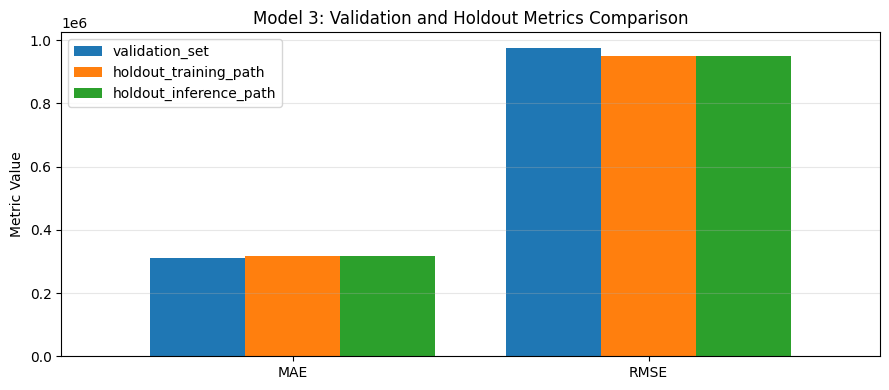

In [110]:
# Plot 1: validation/holdout comparison
# For Model 3, there is no separate raw-input inference wrapper,
# so the two holdout bars are the same by construction.
m3_compare = pd.DataFrame(
    {
        "validation_set": [
            validation_results_m3["mae"],
            validation_results_m3["rmse"],
        ],
        "holdout_training_path": [
            holdout_results_m3["mae"],
            holdout_results_m3["rmse"],
        ],
        "holdout_inference_path": [
            holdout_results_m3["mae"],
            holdout_results_m3["rmse"],
        ],
    },
    index=["MAE", "RMSE"],
)

ax = m3_compare.plot(kind="bar", figsize=(9, 4), rot=0, width=0.8)
ax.set_title("Model 3: Validation and Holdout Metrics Comparison")
ax.set_ylabel("Metric Value")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

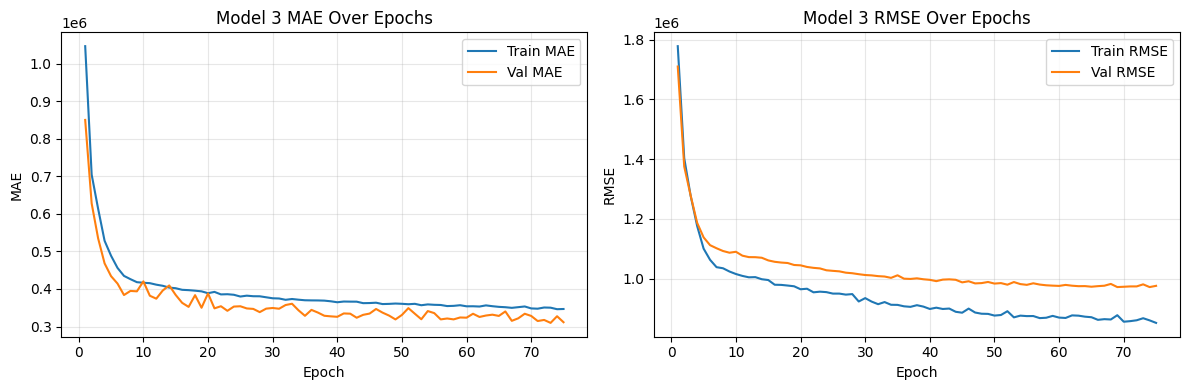

In [111]:
# Plot 2: training curves
epochs_m3 = range(1, len(history_m3.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_m3, history_m3.history["mae"], label="Train MAE")
axes[0].plot(epochs_m3, history_m3.history["val_mae"], label="Val MAE")
axes[0].set_title("Model 3 MAE Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_m3, history_m3.history["rmse"], label="Train RMSE")
axes[1].plot(epochs_m3, history_m3.history["val_rmse"], label="Val RMSE")
axes[1].set_title("Model 3 RMSE Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


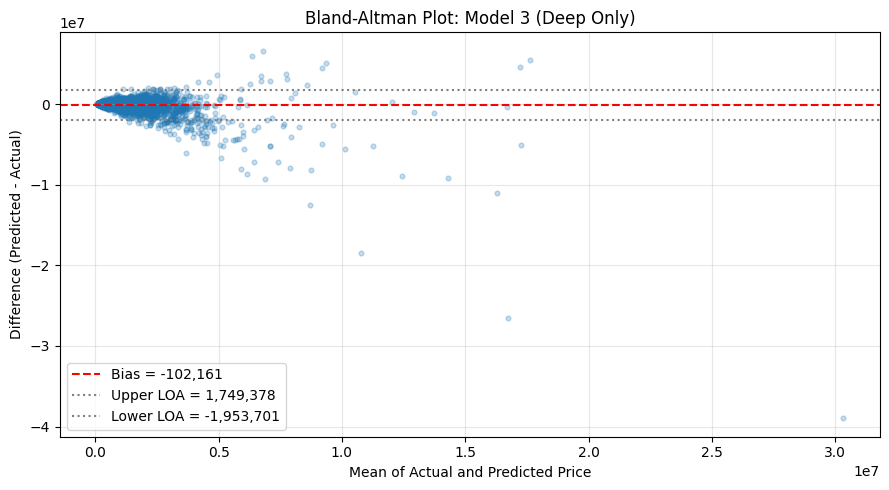

Model 3 Bias: -102,161.34
Model 3 Upper LOA: 1,749,378.38
Model 3 Lower LOA: -1,953,701.12


In [112]:
# Plot 3: Bland-Altman
actual_m3 = y_true_m3
predicted_m3 = y_pred_m3
mean_vals_m3 = (actual_m3 + predicted_m3) / 2
diff_vals_m3 = predicted_m3 - actual_m3

bias_m3 = diff_vals_m3.mean()
sd_m3 = diff_vals_m3.std(ddof=1)
loa_upper_m3 = bias_m3 + 1.96 * sd_m3
loa_lower_m3 = bias_m3 - 1.96 * sd_m3

plt.figure(figsize=(9, 5))
plt.scatter(mean_vals_m3, diff_vals_m3, alpha=0.25, s=12)
plt.axhline(bias_m3, color="red", linestyle="--", label=f"Bias = {bias_m3:,.0f}")
plt.axhline(loa_upper_m3, color="gray", linestyle=":", label=f"Upper LOA = {loa_upper_m3:,.0f}")
plt.axhline(loa_lower_m3, color="gray", linestyle=":", label=f"Lower LOA = {loa_lower_m3:,.0f}")
plt.title("Bland-Altman Plot: Model 3 (Deep Only)")
plt.xlabel("Mean of Actual and Predicted Price")
plt.ylabel("Difference (Predicted - Actual)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Model 3 Bias: {bias_m3:,.2f}")
print(f"Model 3 Upper LOA: {loa_upper_m3:,.2f}")
print(f"Model 3 Lower LOA: {loa_lower_m3:,.2f}")

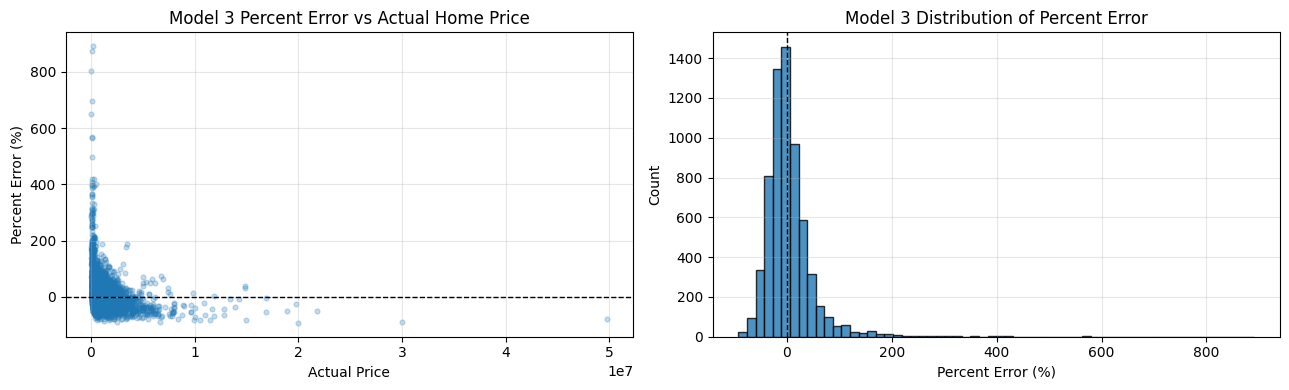

Model 3 Median absolute percent error: 20.68%
Model 3 Mean absolute percent error: 30.14%


,Model,MAE,RMSE,Median Absolute Percent Error (%),Mean Absolute Percent Error (%),Residual Variance
0,Model 1,456960.12,1158565.88,39.82,56.110001,1.326687e+12
1,Model 2,324185.84,943985.00,21.43,33.130001,8.911087e+11
2,Model 3,316613.06,950098.62,20.68,30.139999,8.923884e+11


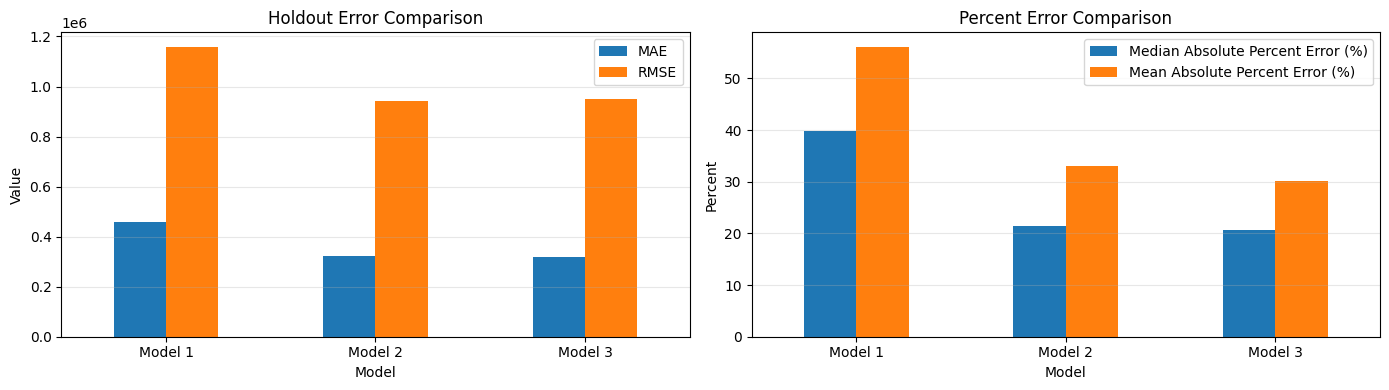

In [113]:
# Plot 4: percent-error diagnostics
percent_error_m3 = 100.0 * (predicted_m3 - actual_m3) / np.maximum(np.abs(actual_m3), 1e-8)
abs_percent_error_m3 = np.abs(percent_error_m3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(actual_m3, percent_error_m3, alpha=0.25, s=12)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Model 3 Percent Error vs Actual Home Price")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Percent Error (%)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(percent_error_m3, bins=60, edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Model 3 Distribution of Percent Error")
axes[1].set_xlabel("Percent Error (%)")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Model 3 Median absolute percent error: {np.median(abs_percent_error_m3):.2f}%")
print(f"Model 3 Mean absolute percent error: {np.mean(abs_percent_error_m3):.2f}%")

# Updated comparison table + plot
percent_error_summary = pd.DataFrame(
    {
        "Model": ["Model 1", "Model 2", "Model 3"],
        "MAE": [
            train_results["mae"],
            m2_test_mae,
            holdout_results_m3["mae"],
        ],
        "RMSE": [
            train_results["rmse"],
            m2_test_rmse,
            holdout_results_m3["rmse"],
        ],
        "Median Absolute Percent Error (%)": [
            np.median(abs_percent_error),
            np.median(abs_percent_error_m2),
            np.median(abs_percent_error_m3),
        ],
        "Mean Absolute Percent Error (%)": [
            np.mean(abs_percent_error),
            np.mean(abs_percent_error_m2),
            np.mean(abs_percent_error_m3),
        ],
        "Residual Variance": [
            float(np.var(y_true - y_pred_infer, ddof=1)),
            float(np.var(y_true_m2 - y_pred_m2, ddof=1)),
            float(np.var(actual_m3 - predicted_m3, ddof=1)),
        ],
    }
)

percent_error_summary.iloc[:, 1:] = percent_error_summary.iloc[:, 1:].round(2)
display(percent_error_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

percent_error_summary.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar", ax=axes[0], rot=0
)
axes[0].set_title("Holdout Error Comparison")
axes[0].set_ylabel("Value")
axes[0].grid(True, axis="y", alpha=0.3)

percent_error_summary.set_index("Model")[
    ["Median Absolute Percent Error (%)", "Mean Absolute Percent Error (%)"]
].plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Percent Error Comparison")
axes[1].set_ylabel("Percent")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Model 3: Explanation

So, this Model is less complex than Model 2, but it seems slightly better, as measured by MAE and Percent Error metrics.
The RMSE is slightly higher, though, and the Residual Variance. This suggests that removing the
wide part of Model 2, in Model 3, removed some of the accuracy for predicting higher priced homes.

We feel compelled to point out, though, that Models 1 and 2 used 1.6m parameters while Model 3 used only 160k parameters.
This is 10x fewer parameters.

Probably this suggests we need to rework the features we picked for our categorical/crossed embeddings in the wide model.
We can probably also do more tuning of the deep model as well.

We won't be using the **McNemar** comparisons for the three models, since these are regressions.
Instead we'll use somthing similar called: Wilcoxon on paired absolute errors.

But, we'll show the McNemar tables below with a thresholded good/bad prediction label.

,comparison,Model 1_MAE,Model 2_MAE,wilcoxon_stat,p_value,Model 3_MAE
0,Model 1 vs Model 2,456960.125,324185.84375,4896800.5,5.478631e-300,NaN
1,Model 1 vs Model 3,456960.125,NaN,4663263.5,0.000000e+00,316613.0625
2,Model 2 vs Model 3,NaN,324185.84375,9696724.5,4.555857e-07,316613.0625



McNemar-style table: Model 1 vs Model 2


Model 2,Model 2 bad,Model 2 good
Model 1,,
Model 1 bad,2859,1832
Model 1 good,543,1232



McNemar-style table: Model 1 vs Model 3


Model 3,Model 3 bad,Model 3 good
Model 1,,
Model 1 bad,2758,1933
Model 1 good,560,1215



McNemar-style table: Model 2 vs Model 3


Model 3,Model 3 bad,Model 3 good
Model 2,,
Model 2 bad,2551,851
Model 2 good,767,2297


,comparison,threshold_pct,Model 1_only_good,Model 2_only_good,mcnemar_chi2,p_value,Model 3_only_good
0,Model 1 vs Model 2,20.0,543.0,1832.0,698.502737,2.100410e-162,NaN
1,Model 1 vs Model 3,20.0,560.0,NaN,755.067790,1.048863e-175,1933.0
2,Model 2 vs Model 3,20.0,NaN,767.0,4.257726,3.903932e-02,851.0


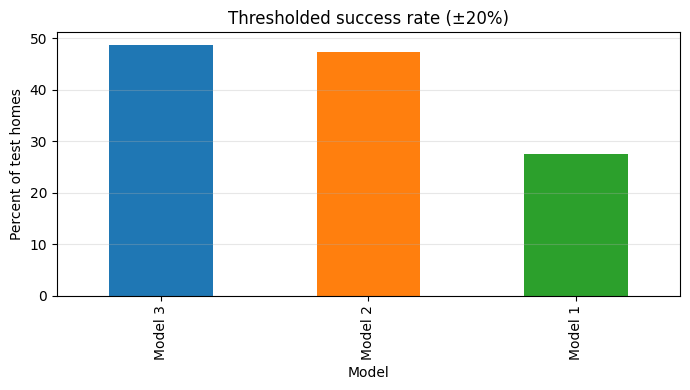

In [115]:
from itertools import combinations
from scipy.stats import wilcoxon, binomtest

# Proper regression comparison
abs_error_dict = {
    "Model 1": np.abs(y_true - y_pred_infer),
    "Model 2": np.abs(y_true - y_pred_m2),
    "Model 3": np.abs(y_true - y_pred_m3),
}

regression_rows = []
for a, b in combinations(abs_error_dict.keys(), 2):
    stat, p = wilcoxon(
        abs_error_dict[a],
        abs_error_dict[b],
        zero_method="wilcox",
        alternative="two-sided",
        method="auto",
    )
    regression_rows.append({
        "comparison": f"{a} vs {b}",
        f"{a}_MAE": float(abs_error_dict[a].mean()),
        f"{b}_MAE": float(abs_error_dict[b].mean()),
        "wilcoxon_stat": float(stat),
        "p_value": float(p),
    })

regression_compare_df = pd.DataFrame(regression_rows)
display(regression_compare_df)

# Optional McNemar-style workaround:
# define "good" prediction as absolute percent error within threshold
threshold_pct = 20.0
good_pred = {
    "Model 1": np.abs(percent_error) <= threshold_pct,
    "Model 2": np.abs(percent_error_m2) <= threshold_pct,
    "Model 3": np.abs(percent_error_m3) <= threshold_pct,
}

mcnemar_rows = []

for a, b in combinations(good_pred.keys(), 2):
    table = pd.crosstab(
        pd.Series(good_pred[a], name=a),
        pd.Series(good_pred[b], name=b),
    ).reindex(index=[False, True], columns=[False, True], fill_value=0)

    b_only_good = int(table.loc[False, True])
    a_only_good = int(table.loc[True, False])
    n_discordant = a_only_good + b_only_good

    if n_discordant == 0:
        chi2_stat = 0.0
        p_value = 1.0
    else:
        chi2_stat = (abs(a_only_good - b_only_good) - 1) ** 2 / n_discordant
        p_value = binomtest(min(a_only_good, b_only_good), n=n_discordant, p=0.5).pvalue

    print(f"\nMcNemar-style table: {a} vs {b}")
    display(
        table.rename(
            index={False: f"{a} bad", True: f"{a} good"},
            columns={False: f"{b} bad", True: f"{b} good"},
        )
    )

    mcnemar_rows.append({
        "comparison": f"{a} vs {b}",
        "threshold_pct": threshold_pct,
        f"{a}_only_good": a_only_good,
        f"{b}_only_good": b_only_good,
        "mcnemar_chi2": float(chi2_stat),
        "p_value": float(p_value),
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)
display(mcnemar_df)

# Simple visual for the thresholded comparison
success_rate_df = pd.DataFrame({
    "Model": list(good_pred.keys()),
    f"Within ±{int(threshold_pct)}%": [100 * v.mean() for v in good_pred.values()],
}).sort_values(f"Within ±{int(threshold_pct)}%", ascending=False)

ax = success_rate_df.plot(
    kind="bar",
    x="Model",
    y=f"Within ±{int(threshold_pct)}%",
    legend=False,
    figsize=(7, 4),
    color=["tab:blue", "tab:orange", "tab:green"],
)
ax.set_ylabel("Percent of test homes")
ax.set_title(f"Thresholded success rate (±{int(threshold_pct)}%)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

These McNemar style pairwise comparisons suggest that Model 3 is the best.
Model 3 is consistently the highest "only_good" measure, and all of the p_values are small,
suggesting that the observed differences are statistically meaningful, and not random.
Interestingly, there aren't many

## Exceptional Work

### Exceptional work: visualize learned embeddings from Model 2

For the required 7000-level exceptional work, we use the **trained embeddings from Model 2** rather than building more model-depth comparisons.

In the code below, we:

1. pass a sample of homes through the trained network,
2. capture the learned **deep embedding representation** for each observation,
3. use **PCA** to reduce those embeddings to two dimensions,
4. visualize whether homes cluster by **property type** and **price tier**, and
5. inspect the learned **City embeddings** directly with a 2D projection and a similarity heatmap.

These plots help show whether the network has learned meaningful latent structure in the data.

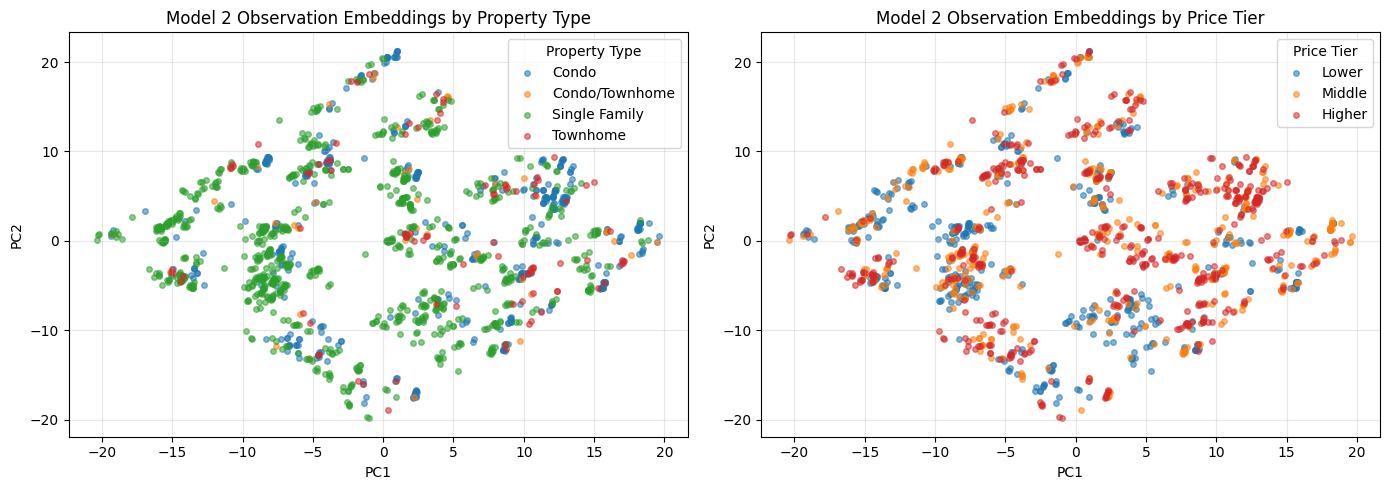

In [118]:
# Exceptional work for the 7000-level requirement:
# capture learned embeddings from Model 2 and visualize clusters in the data.

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------------------------------------
# 1) Pass a sample of homes through Model 2 and capture the
#    learned deep-embedding representation for each observation.
# -------------------------------------------------------------
sample_n = min(1500, len(X_test))
sample_idx = X_test.sample(n=sample_n, random_state=42).index
X_embed_sample = X_test.loc[sample_idx].copy()
y_embed_sample = y_test.loc[sample_idx].copy()

sample_ds = tf.data.Dataset.from_tensor_slices(
    (dict(X_embed_sample), y_embed_sample.values)
).batch(sample_n)

encoded_sample_batch, _ = next(
    iter(
        sample_ds.map(
            lambda x, y: (feature_space(x), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
    )
)

embedding_extractor_m2 = keras.Model(
    inputs=training_model_m2.inputs,
    outputs=training_model_m2.get_layer("embed_concat_m2").output,
    name="model_2_embedding_extractor",
)

obs_embeddings_m2 = embedding_extractor_m2.predict(encoded_sample_batch, verbose=0)

obs_pca = PCA(n_components=2, random_state=42)
obs_2d = obs_pca.fit_transform(obs_embeddings_m2)

viz_df = pd.DataFrame(obs_2d, columns=["PC1", "PC2"], index=X_embed_sample.index)
viz_df["Property_Type"] = X_embed_sample["Property_Type"].astype(str).values
viz_df["Price"] = y_embed_sample.values
viz_df["Price_Tier"] = pd.qcut(
    viz_df["Price"], q=3, labels=["Lower", "Middle", "Higher"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for prop_type in sorted(viz_df["Property_Type"].unique()):
    mask = viz_df["Property_Type"] == prop_type
    axes[0].scatter(
        viz_df.loc[mask, "PC1"],
        viz_df.loc[mask, "PC2"],
        s=16,
        alpha=0.55,
        label=prop_type,
    )

axes[0].set_title("Model 2 Observation Embeddings by Property Type")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="Property Type")

price_colors = {"Lower": "tab:blue", "Middle": "tab:orange", "Higher": "tab:red"}
for tier, color in price_colors.items():
    mask = viz_df["Price_Tier"] == tier
    axes[1].scatter(
        viz_df.loc[mask, "PC1"],
        viz_df.loc[mask, "PC2"],
        s=16,
        alpha=0.55,
        color=color,
        label=tier,
    )

axes[1].set_title("Model 2 Observation Embeddings by Price Tier")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)
axes[1].legend(title="Price Tier")

plt.tight_layout()
plt.show()


#### Step 1: explanation

For this first embedding analysis, we randomly sampled **1,500 homes** from the **holdout test set** using a fixed random seed of **42** so the sample would be reproducible. We then passed those homes through **Model 2** and extracted the learned deep embedding representation for each observation before reducing that representation to two dimensions with **PCA**.

In the plot, homes that appear close together are homes the network considers similar in its learned feature space. The separation by **price tier** is stronger than the separation by **property type**, which suggests the model learned latent patterns that are closely related to home value. In our run, the first two principal components explained about **63.42%** of the variation in the sampled observation embeddings, so the 2D view preserves a meaningful amount of the learned structure.

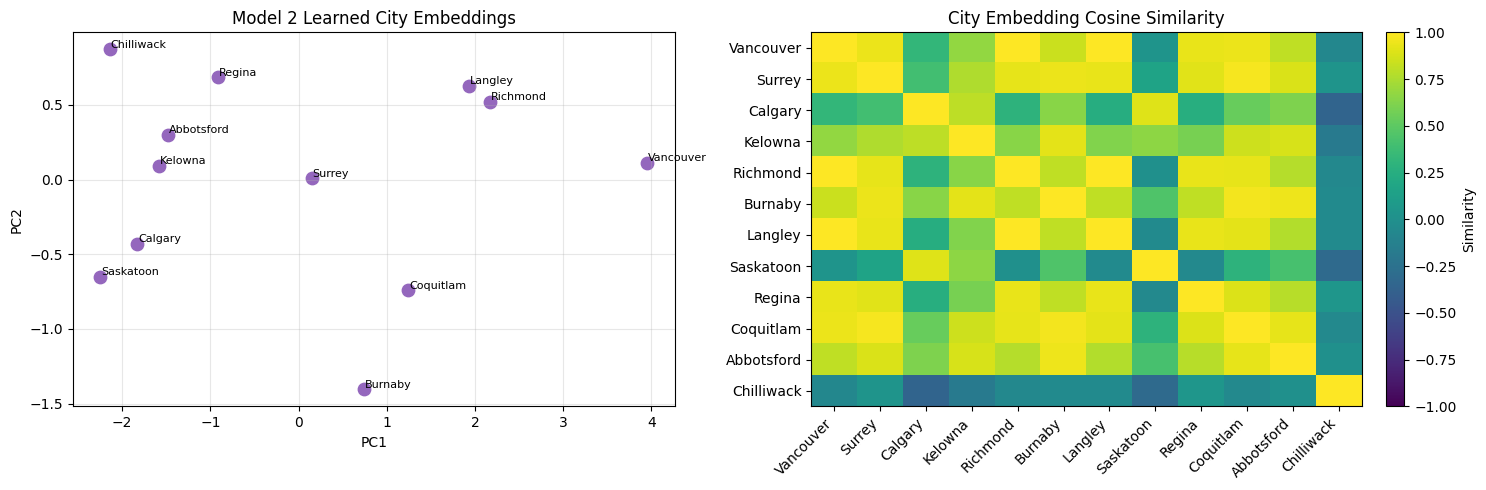

Observation-embedding PCA explained variance: 63.42%
City-embedding PCA explained variance: 96.07%
Cities or homes that appear close together in these plots are being treated by the network as having similar pricing patterns.


In [120]:
# -------------------------------------------------------------
# 2) Extract the learned City embedding weights directly and
#    visualize which cities are close in embedding space.
# -------------------------------------------------------------
city_vocab = feature_space.preprocessors["City"].get_vocabulary()
city_weights = training_model_m2.get_layer("City_embed_m2").get_weights()[0]

top_cities = [
    city for city in X_train["City"].value_counts().head(12).index
    if city in city_vocab
]
city_indices = [city_vocab.index(city) for city in top_cities]
city_vectors = city_weights[city_indices]

city_pca = PCA(n_components=2, random_state=42)
city_2d = city_pca.fit_transform(city_vectors)
city_sim = cosine_similarity(city_vectors)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(city_2d[:, 0], city_2d[:, 1], s=80, color="tab:purple")
for i, city in enumerate(top_cities):
    axes[0].text(city_2d[i, 0] + 0.01, city_2d[i, 1] + 0.01, city, fontsize=8)
axes[0].set_title("Model 2 Learned City Embeddings")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(city_sim, cmap="viridis", vmin=-1, vmax=1, aspect="auto")
axes[1].set_title("City Embedding Cosine Similarity")
axes[1].set_xticks(range(len(top_cities)))
axes[1].set_xticklabels(top_cities, rotation=45, ha="right")
axes[1].set_yticks(range(len(top_cities)))
axes[1].set_yticklabels(top_cities)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Similarity")

plt.tight_layout()
plt.show()

print(f"Observation-embedding PCA explained variance: {obs_pca.explained_variance_ratio_.sum():.2%}")
print(f"City-embedding PCA explained variance: {city_pca.explained_variance_ratio_.sum():.2%}")
print("Cities or homes that appear close together in these plots are being treated by the network as having similar pricing patterns.")

#### Step 2: explanation

In the second step, we inspected the learned **City embedding weights** directly from **Model 2**. We focused on the **12 most common cities** in the training data, projected those city embeddings into two dimensions with **PCA**, and also computed a **cosine-similarity heatmap**.

Cities that appear close together in the scatterplot, or that have brighter similarity values in the heatmap, are being treated by the network as having similar pricing behavior. This means the model has learned a useful latent representation of geographic market similarity rather than just memorizing city names independently. In our run, the first two principal components explained about **96.07%** of the variation in the city embeddings, which indicates that the clustering pattern is especially clear and interpretable.

## Conclusion

In this lab, we successfully completed the full workflow for a housing-price regression problem using wide-and-deep neural networks.

Our main accomplishments were:

- cleaning and preparing the Canadian housing dataset for modeling,
- creating a proper **train / validation / test** split with stratification by price range,
- engineering useful **discretized** and **crossed** features,
- building TensorFlow input pipelines and preprocessing with **FeatureSpace**,
- training and comparing **three regression models**,
- evaluating them with appropriate regression metrics such as **MAE**, **RMSE**, **percent error**, **residual variance**, and **Bland–Altman plots**, and
- identifying that the later tuned models improved substantially over the original baseline, with **Model 3** finishing as the strongest overall performer by a narrow margin.

For the 7000-level exceptional work, we also extracted and visualized learned embeddings from **Model 2**. These plots showed that the network learned meaningful latent structure in the data, including similarities across home price tiers and across city-level market patterns.

Overall, this lab demonstrated both the predictive value and the benefits of using wide-and-deep neural networks for real-world regression tasks.

### One more note on AI assist

Even with AI assist this lab took many, many hours. Working with a new data set took a long time. Working with the new model code
took even longer. We used AI assist to write almost every section of code in this lab. But, it now seems more like a useful tool
than a proxy for us learning and thinking about these challenges.